In [1]:
import sys
# Install necessary libraries
!{sys.executable} -m pip install gdown

In [2]:
import gdown #download files(dataset) directly from Google Drive.
import os # operating system module for interacting with the operating system
import zipfile # Import the zipfile module
import numpy as np # for numerical operations, especially with arrays
import pandas as pd # for organizing data in tables (DataFrames) and doing all sorts of operations on them.

import matplotlib.pyplot as plt # for making basic plots and charts to visualize our data.
import seaborn as sns # seaborn: This builds on matplotlib and gives us even prettier and more informative statistical plots with less code.

# Scikit-learn and imblearn imports
from sklearn.experimental import enable_halving_search_cv # Explicitly enable experimental HalvingGridSearchCV
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, HalvingGridSearchCV, HalvingRandomSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, auc
from sklearn.feature_selection import RFE
from sklearn.ensemble import BaggingClassifier

# Other utility imports
import warnings

In [3]:
gdrive_url = 'https://drive.google.com/file/d/1Jg0hqQQBOAt3GevTYh9SVXB7tZWlAQ_Q/view?usp=drive_link'
save_zip_as = 'bank_dataset.zip'

print(f"Downloading {gdrive_url} and saving as {save_zip_as}...")
# Download the file
gdown.download(gdrive_url, save_zip_as, fuzzy=True)
print(f"Downloaded to {save_zip_as}")

# Unzip the file
print(f"Unzipping {save_zip_as}...")
with zipfile.ZipFile(save_zip_as, 'r') as zip_ref:
    zip_ref.extractall('.')
print("Unzipping complete.")

# Remove the zip file after extraction to save space
os.remove(save_zip_as)
print(f"Removed {save_zip_as}")

# Define the dataset path after extraction
dataset_path = '/content'
print(f"Extracted dataset should be available at: {dataset_path}")

Downloading...
From: https://drive.google.com/uc?id=1Jg0hqQQBOAt3GevTYh9SVXB7tZWlAQ_Q
To: /content/bank_dataset.zip
100%|██████████| 516k/516k [00:00<00:00, 68.0MB/s]

Downloaded to bank_dataset.zip
Unzipping bank_dataset.zip...
Unzipping complete.
Removed bank_dataset.zip
Extracted dataset should be available at: /content


## 1. EDA

### 1.1 Load dataset into dataframe and categorize features

In [4]:
df = pd.read_csv('/content/bank-data/bank-full.csv', sep=';')
display(df.head())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
numerical_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']
temporal_features = ['month', 'day']

print(f"Numerical features({len(numerical_features)}): {numerical_features}")
print(f"Categorical features({len(categorical_features)}): {categorical_features}")
print(f"Temporal features({len(temporal_features)}): {temporal_features}")

Numerical features(6): ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
Categorical features(8): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']
Temporal features(2): ['month', 'day']


### 1.2 Calculate and visualize missing values

In [6]:
# Define missing values based on problem description
missing_values = ['unknown', -1]

# Calculate missing percentages and total counts for all columns in df
missing_percentages = {}
total_missing_counts = {}
for col in df.columns:
    # Count 'unknown' strings
    unknown_count = df[col].astype(str).str.lower().eq('unknown').sum()
    # Count -1 integers (only if the column is numeric)
    neg_one_count = 0
    if pd.api.types.is_numeric_dtype(df[col]):
        neg_one_count = df[col].eq(-1).sum()
    # Count standard NaN values
    nan_count = df[col].isnull().sum()

    total_missing = unknown_count + neg_one_count + nan_count
    missing_percentages[col] = (total_missing / len(df)) * 100
    total_missing_counts[col] = total_missing

# Convert to a DataFrame for easier plotting
missing_df = pd.DataFrame(missing_percentages.items(), columns=['feature', 'missing_percentage'])

# Create a DataFrame for total missing counts
total_missing_df = pd.DataFrame(total_missing_counts.items(), columns=['feature', 'total_missing_count'])

# Merge the two dataframes to show both total counts and percentages
combined_missing_df = pd.merge(total_missing_df, missing_df, on='feature', how='inner')

# Filter out features with 0 missing values and sort by total_missing_count
combined_missing_df = combined_missing_df[combined_missing_df['total_missing_count'] > 0]
combined_missing_df = combined_missing_df.sort_values(by='total_missing_count', ascending=False).reset_index(drop=True)

print("Combined Missing Values Information Per Feature (Including 'unknown' and -1):")
display(combined_missing_df)


Combined Missing Values Information Per Feature (Including 'unknown' and -1):


,feature,total_missing_count,missing_percentage
0,poutcome,36959,81.747805
1,pdays,36954,81.736745
2,contact,13020,28.798301
3,education,1857,4.107407
4,job,288,0.637013
5,balance,50,0.110593


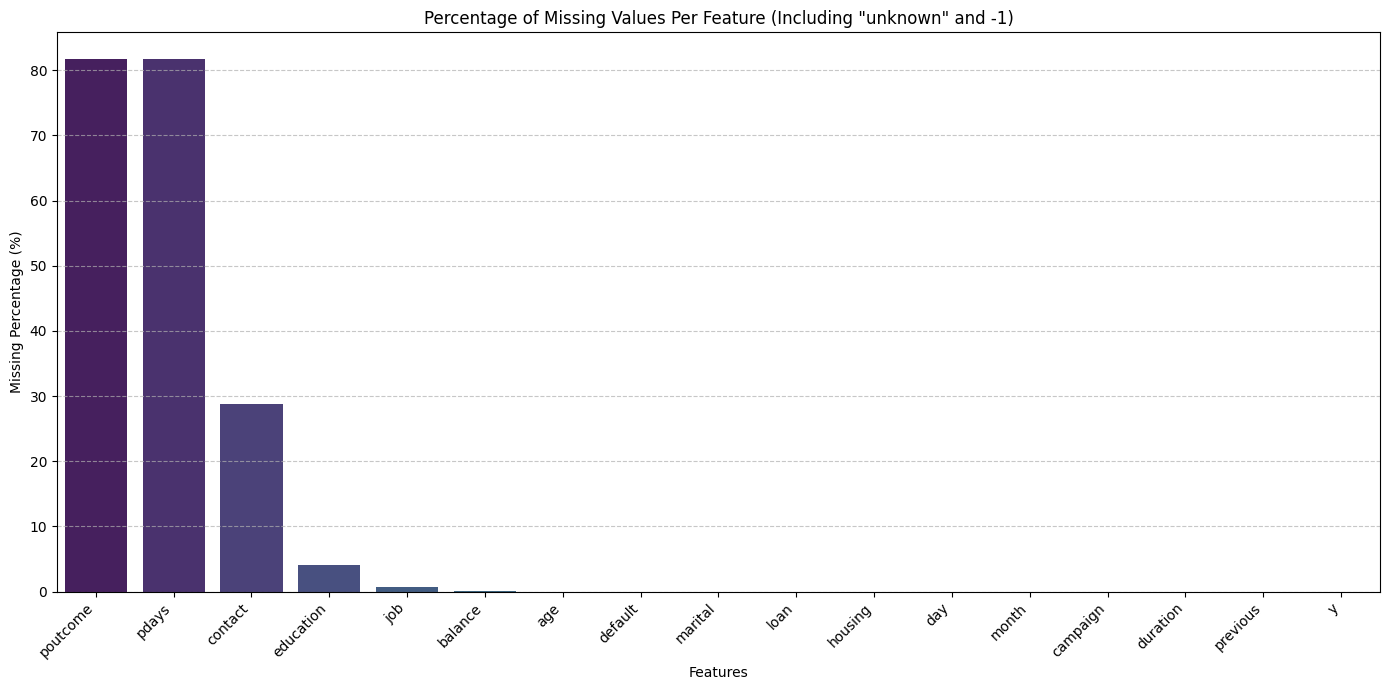

In [7]:
# Sort the missing_df by 'missing_percentage' in descending order
missing_df_sorted = missing_df.sort_values(by='missing_percentage', ascending=False)

# Plotting the missing values
plt.figure(figsize=(14, 7))
sns.barplot(x='feature', y='missing_percentage', data=missing_df_sorted, palette='viridis', hue='feature', legend=False)
plt.title('Percentage of Missing Values Per Feature (Including "unknown" and -1)')
plt.xlabel('Features')
plt.ylabel('Missing Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 1.3 Handling Missing Values

Given the analysis of missing values:
- **`poutcome` and `pdays`**: Both have over 80% missing values (represented as 'unknown' or -1). Imputing such a large proportion of missing data could introduce significant bias or noise. Therefore, these columns will be dropped.
- **`contact`, `education`, `job`**: These are categorical features with missing values (between ~0.6% and ~28%). A common strategy for categorical missing data is to impute with the *mode* (the most frequent value) of the respective column. This preserves the existing distribution as much as possible.
- **`balance`**: This is a numerical feature with a very small percentage of missing values (0.11%). For numerical data, *median* imputation is often preferred over mean imputation when there might be outliers, as the median is less sensitive to extreme values.

In [8]:
# Drop 'poutcome' and 'pdays' due to high percentage of missing values
df_cleaned = df.drop(columns=['poutcome', 'pdays'])
print("Dropped 'poutcome' and 'pdays' columns.")

# Impute categorical features ('contact', 'education', 'job') with mode
for col in ['contact', 'education', 'job']:
    mode_value = df_cleaned[col].mode()[0]
    df_cleaned[col] = df_cleaned[col].replace('unknown', mode_value)
    print(f"Imputed 'unknown' in '{col}' with mode: {mode_value}")

# Impute numerical feature 'balance' with median
median_balance = df_cleaned['balance'].median()
df_cleaned['balance'] = df_cleaned['balance'].replace(-1, median_balance)
print(f"Imputed -1 in 'balance' with median: {median_balance}")

# Verify if any 'unknown' or -1 values remain
print("\nVerifying remaining 'unknown' or -1 values:")
for col in df_cleaned.columns:
    unknown_count = df_cleaned[col].astype(str).str.lower().eq('unknown').sum()
    neg_one_count = 0
    if pd.api.types.is_numeric_dtype(df_cleaned[col]):
        neg_one_count = df_cleaned[col].eq(-1).sum()
    if unknown_count > 0 or neg_one_count > 0:
        print(f"Column '{col}': 'unknown' count = {unknown_count}, -1 count = {neg_one_count}")

print("\nFirst 5 rows of the cleaned DataFrame:")
display(df_cleaned.head())


Dropped 'poutcome' and 'pdays' columns.
Imputed 'unknown' in 'contact' with mode: cellular
Imputed 'unknown' in 'education' with mode: secondary
Imputed 'unknown' in 'job' with mode: blue-collar
Imputed -1 in 'balance' with median: 448.0

Verifying remaining 'unknown' or -1 values:

First 5 rows of the cleaned DataFrame:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,previous,y
0,58,management,married,tertiary,no,2143,yes,no,cellular,5,may,261,1,0,no
1,44,technician,single,secondary,no,29,yes,no,cellular,5,may,151,1,0,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,cellular,5,may,76,1,0,no
3,47,blue-collar,married,secondary,no,1506,yes,no,cellular,5,may,92,1,0,no
4,33,blue-collar,single,secondary,no,1,no,no,cellular,5,may,198,1,0,no


In [9]:
print(df_cleaned.dtypes)

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
previous      int64
y            object
dtype: object


### 1.4 Correlation Analysis using Heatmap

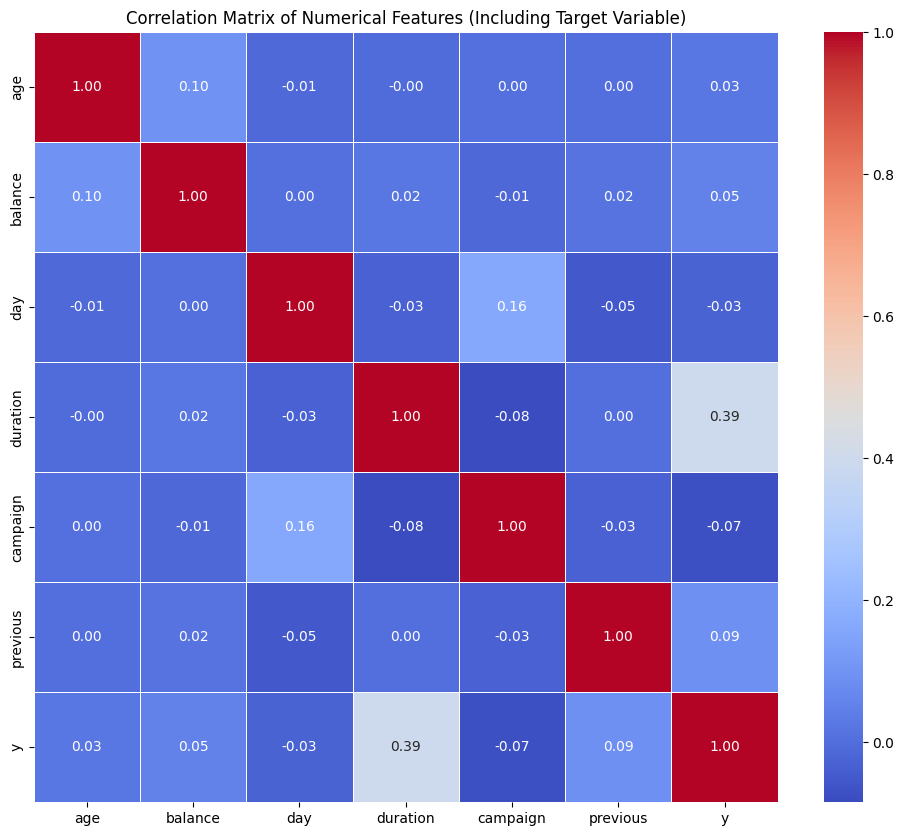

In [10]:
# Ensure 'y' column is numerical (0 for 'no', 1 for 'yes')
# This step was already performed, but it's good practice to re-ensure if this cell was run in isolation.
if df_cleaned['y'].dtype == 'object':
    df_cleaned['y'] = df_cleaned['y'].map({'no': 0, 'yes': 1})

# Select all numerical features for correlation analysis, including the new 'y' column
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns
correlation_matrix = df_cleaned[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features (Including Target Variable)')
plt.show()

#### Heatmap Summary:

*   **Strongest Positive Correlation with 'y':** `duration` (0.39) - Longer call duration means higher chance of subscription as it typically  indicates a more engaged conversation between the bank representative and the potential customer.
*   **Strongest Negative Correlation with 'y':** `campaign` (-0.07) - More contacts during campaign means slightly lower chance of subscription.If a customer is not interested after a few contacts, more contacts might simply irritate them, leading to a 'no'.
*   Most other numerical features have very **weak correlations** with 'y'.

### 1.5 Visualize Categorical Features(Nominal + Ordinal)

#### 1.5.1 Proportion of 'Yes' Responses for Nominal Features

Generating Bar Plots for Proportion of 'Yes' in Nominal Features:


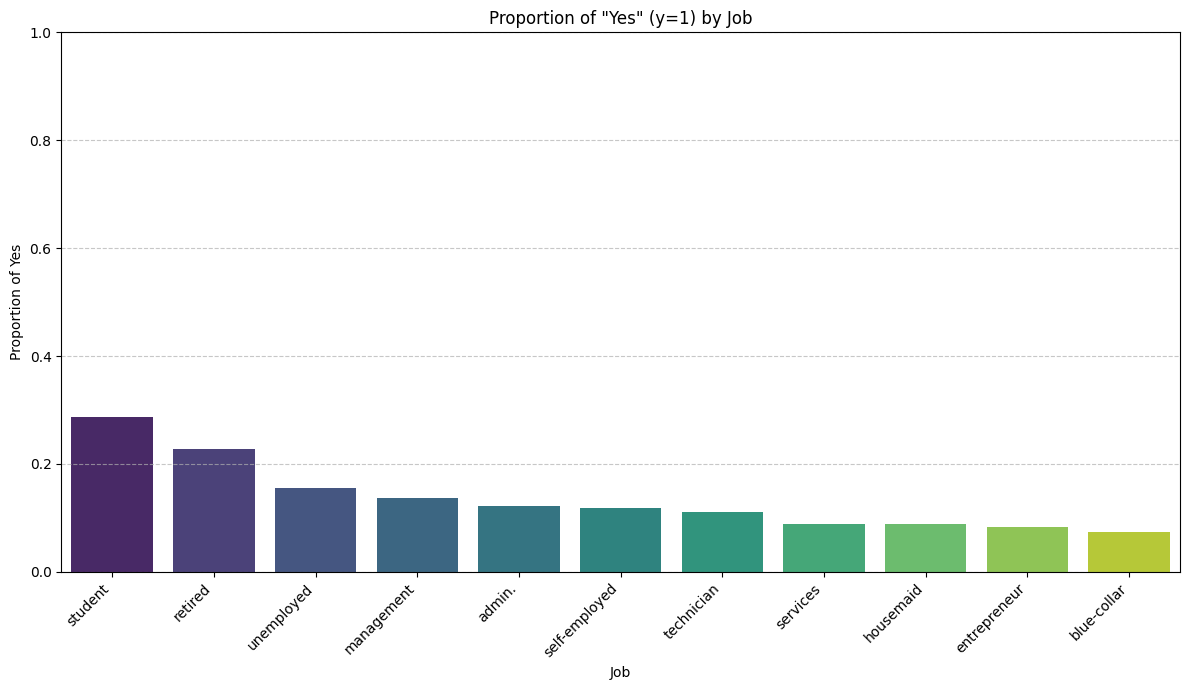

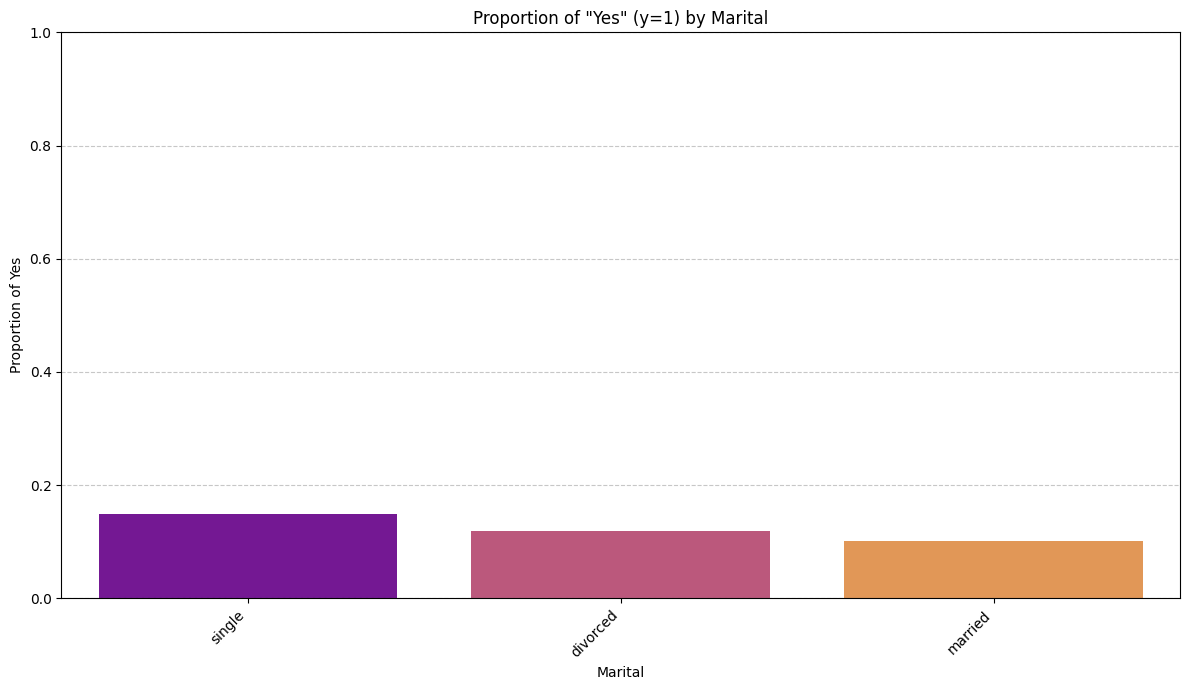

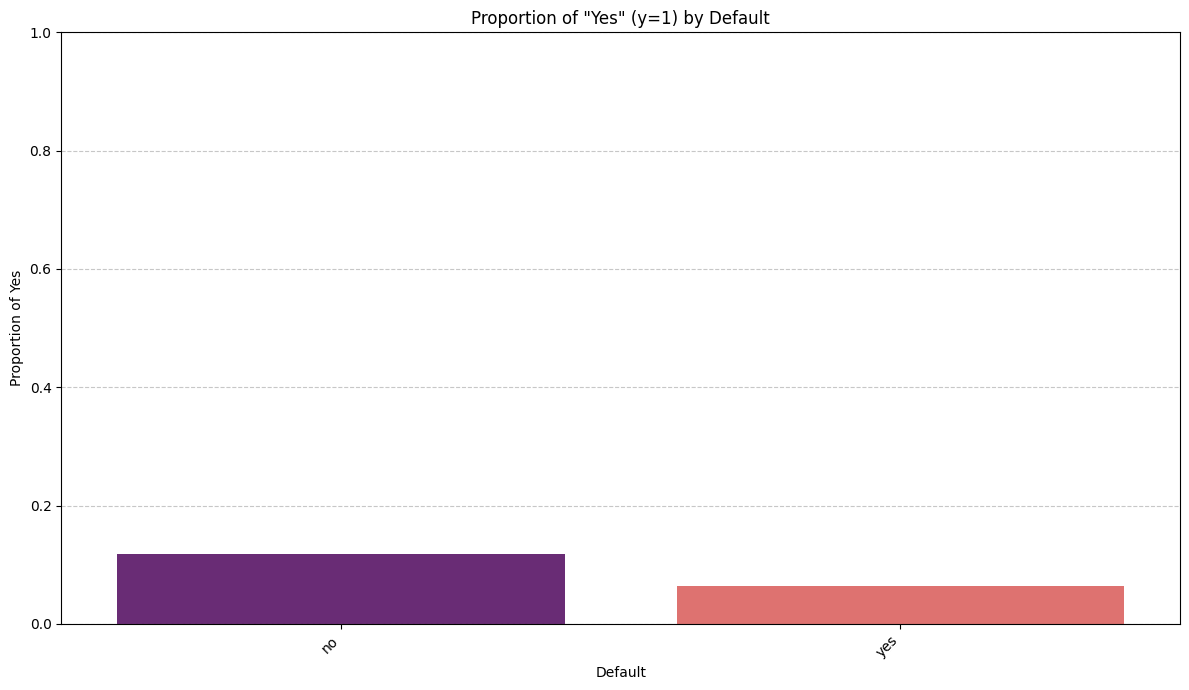

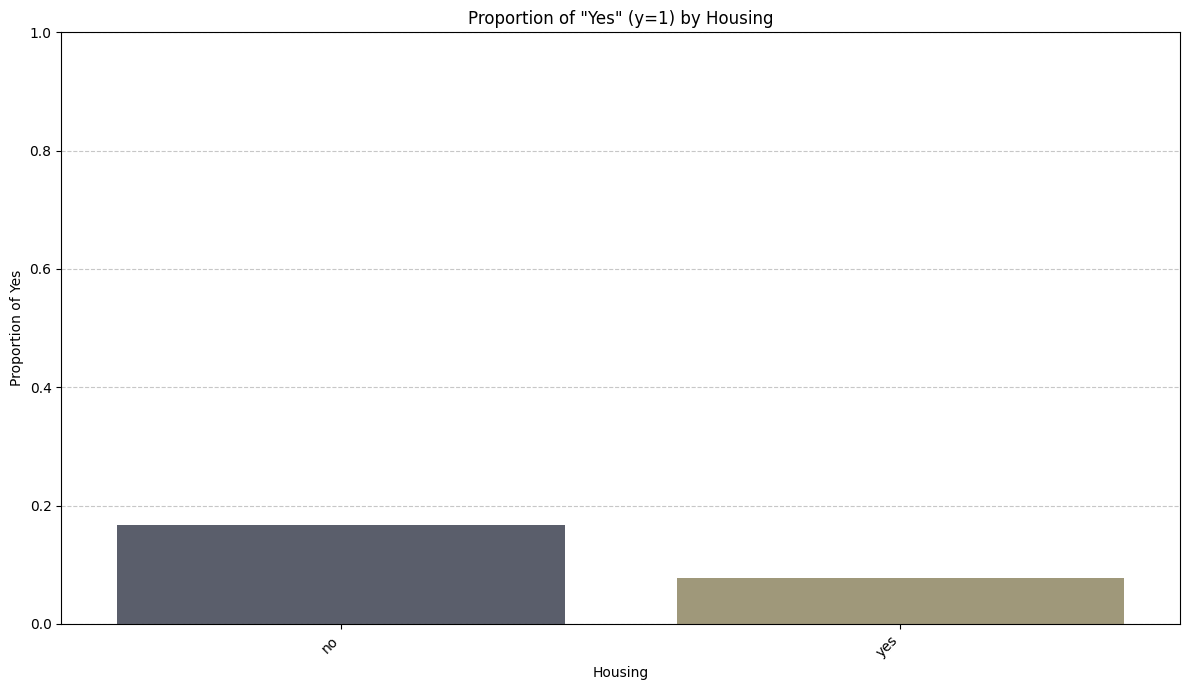

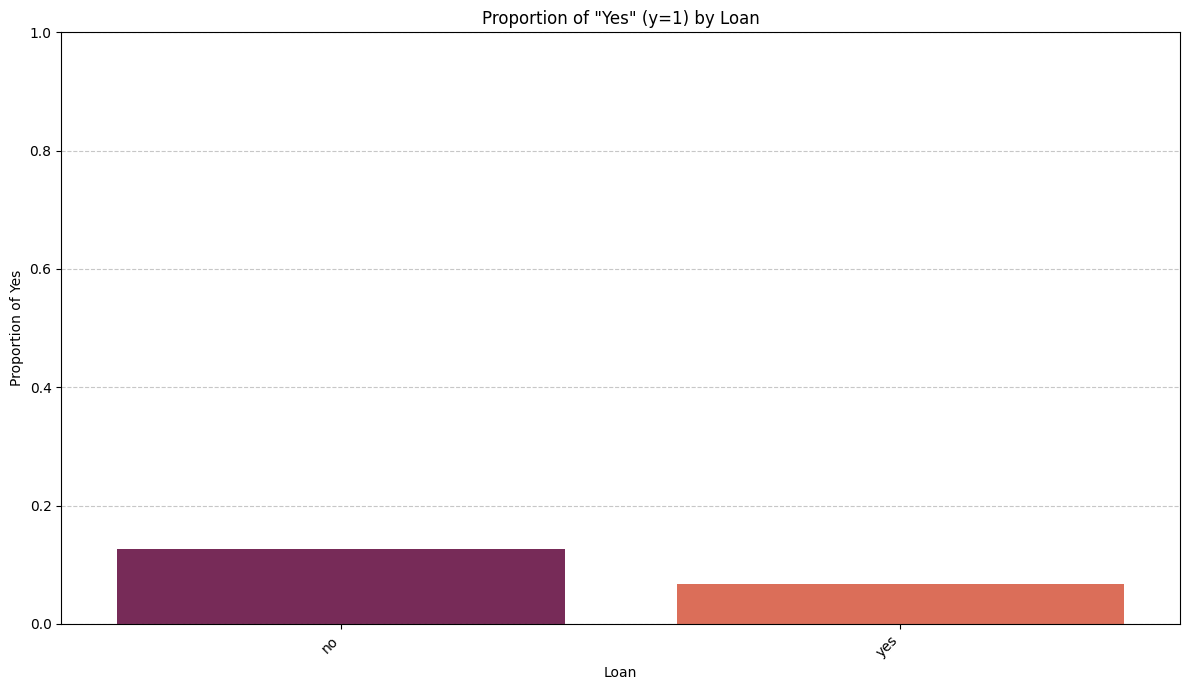

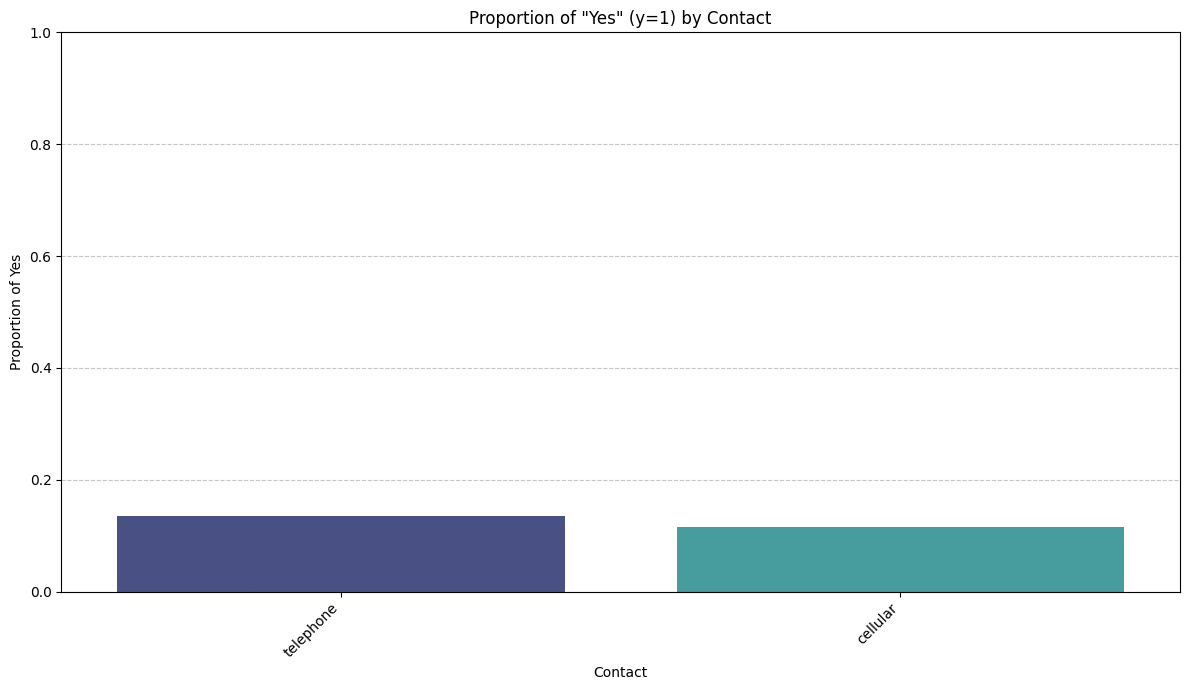

In [11]:
# Define the nominal features explicitly
nominal_features = ['job', 'marital', 'default', 'housing', 'loan', 'contact']

# Define a list of palettes to cycle through
palettes = ['viridis', 'plasma', 'magma', 'cividis', 'rocket', 'mako']

print("Generating Bar Plots for Proportion of 'Yes' in Nominal Features:")
for i, col in enumerate(nominal_features):
    # Calculate the proportion of 'yes' for each category
    proportion_df = df_cleaned.groupby(col)['y'].mean().reset_index()
    proportion_df = proportion_df.sort_values(by='y', ascending=False)

    plt.figure(figsize=(12, 7))
    sns.barplot(x=col, y='y', data=proportion_df, palette=palettes[i % len(palettes)], hue=col, legend=False)
    plt.title(f'Proportion of "Yes" (y=1) by {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Proportion of Yes')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1) # Ensure y-axis is from 0 to 1 for proportions
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

#### 1.5.2 Proportion of 'Yes' Responses for Ordinal Features

Generating Bar Plot for Proportion of 'Yes' in Ordinal Feature: Education:


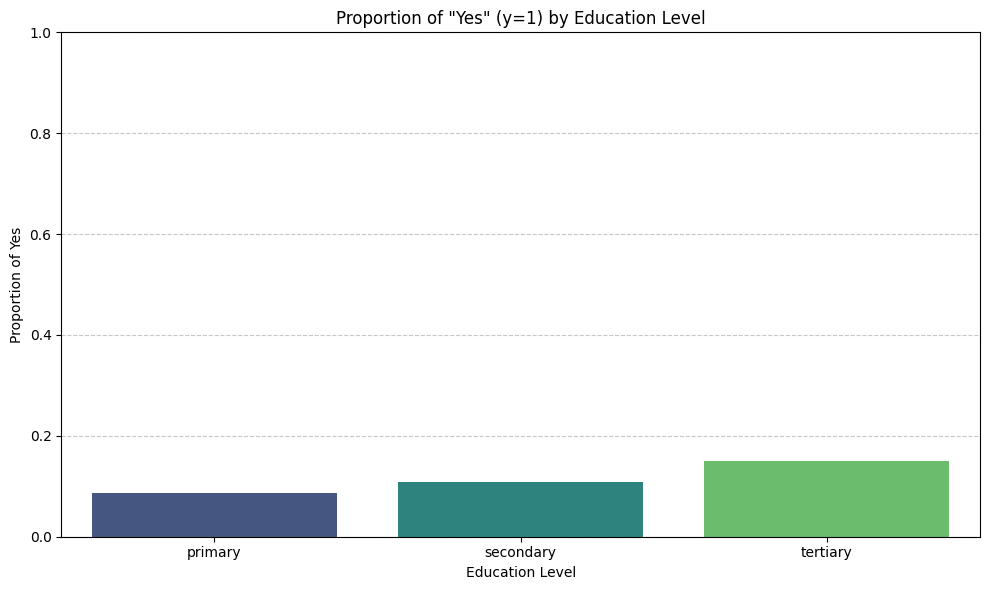

In [12]:
# Define the ordinal feature and its order
ordinal_feature = 'education'
education_order = ['primary', 'secondary', 'tertiary']

print(f"Generating Bar Plot for Proportion of 'Yes' in Ordinal Feature: {ordinal_feature.capitalize()}:")

# Calculate the proportion of 'yes' for each category
proportion_df_ordinal = df_cleaned.groupby(ordinal_feature)['y'].mean().reset_index()

# Sort the DataFrame by the predefined ordinal order
proportion_df_ordinal['education'] = pd.Categorical(proportion_df_ordinal['education'], categories=education_order, ordered=True)
proportion_df_ordinal = proportion_df_ordinal.sort_values(by=ordinal_feature)

plt.figure(figsize=(10, 6))
sns.barplot(x=ordinal_feature, y='y', data=proportion_df_ordinal, palette='viridis', hue=ordinal_feature, legend=False)
plt.title(f'Proportion of "Yes" (y=1) by {ordinal_feature.capitalize()} Level')
plt.xlabel(f'{ordinal_feature.capitalize()} Level')
plt.ylabel('Proportion of Yes')
plt.ylim(0, 1) # Ensure y-axis is from 0 to 1 for proportions
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 1.6 Visualize Numerical Features

Generating KDE and Box Plots for Numerical Features vs. Target 'y':


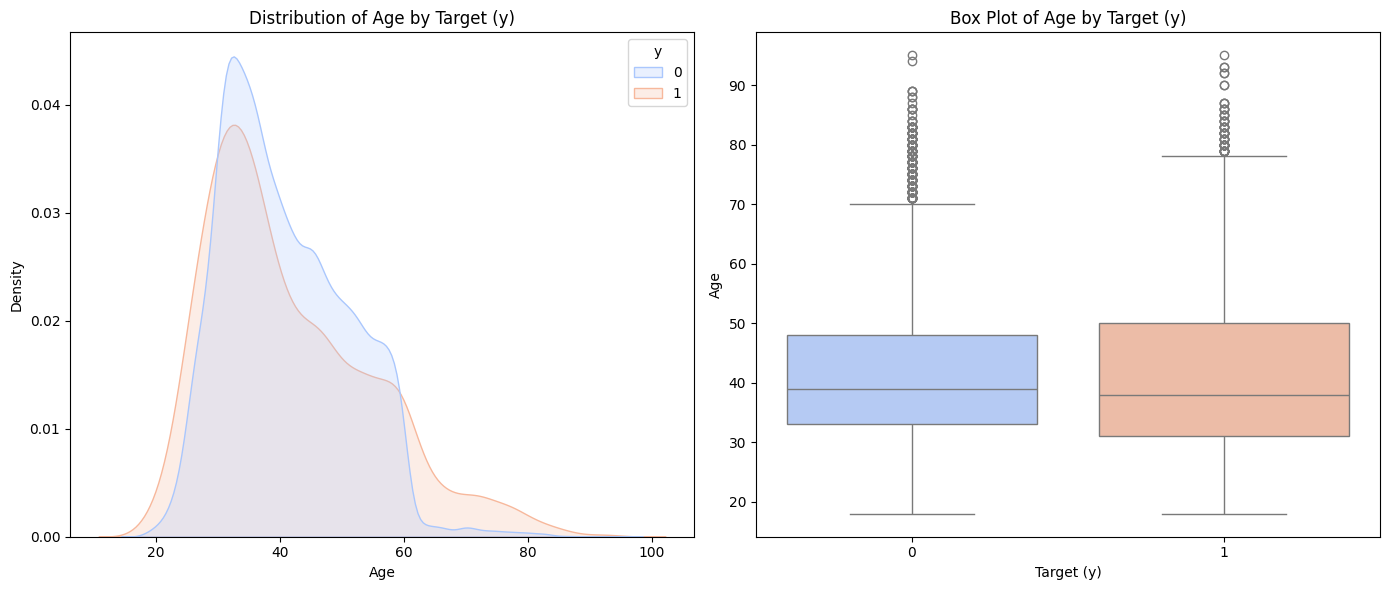

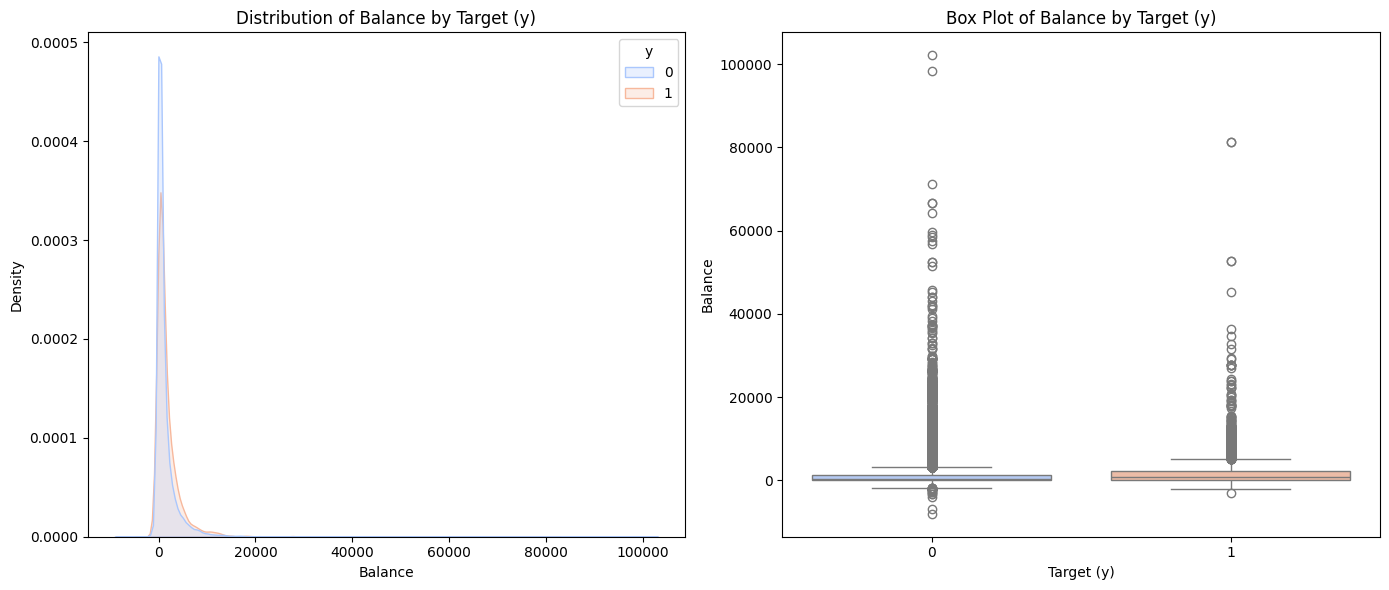

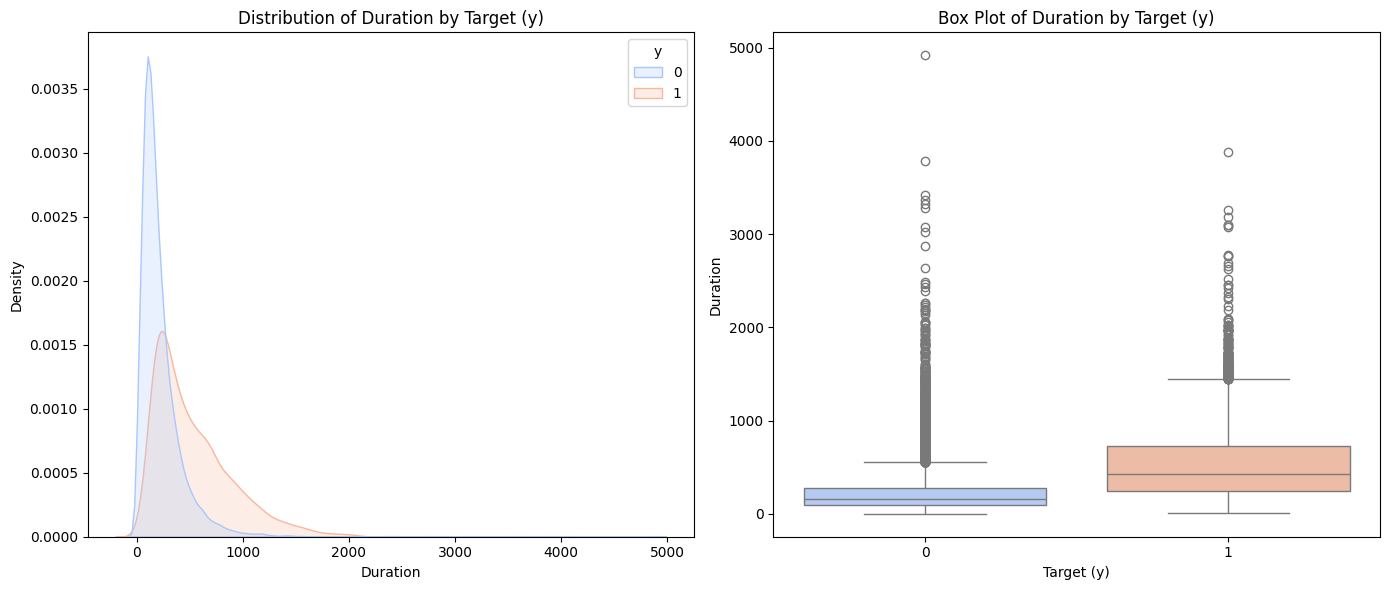

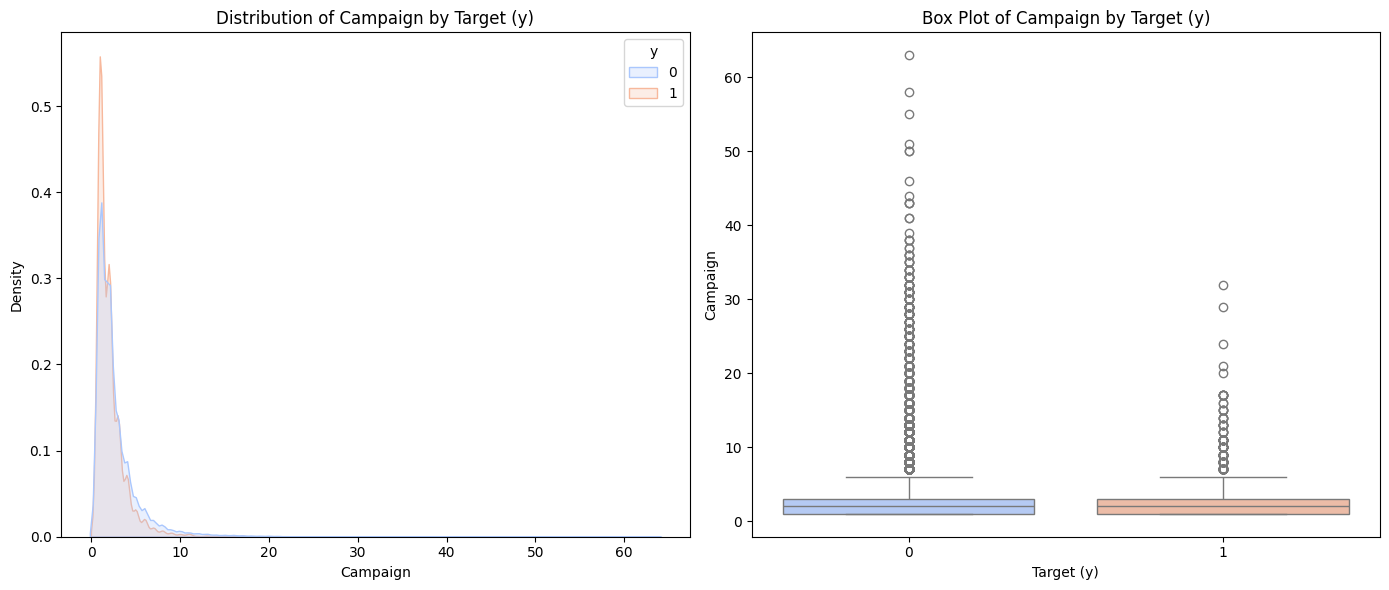

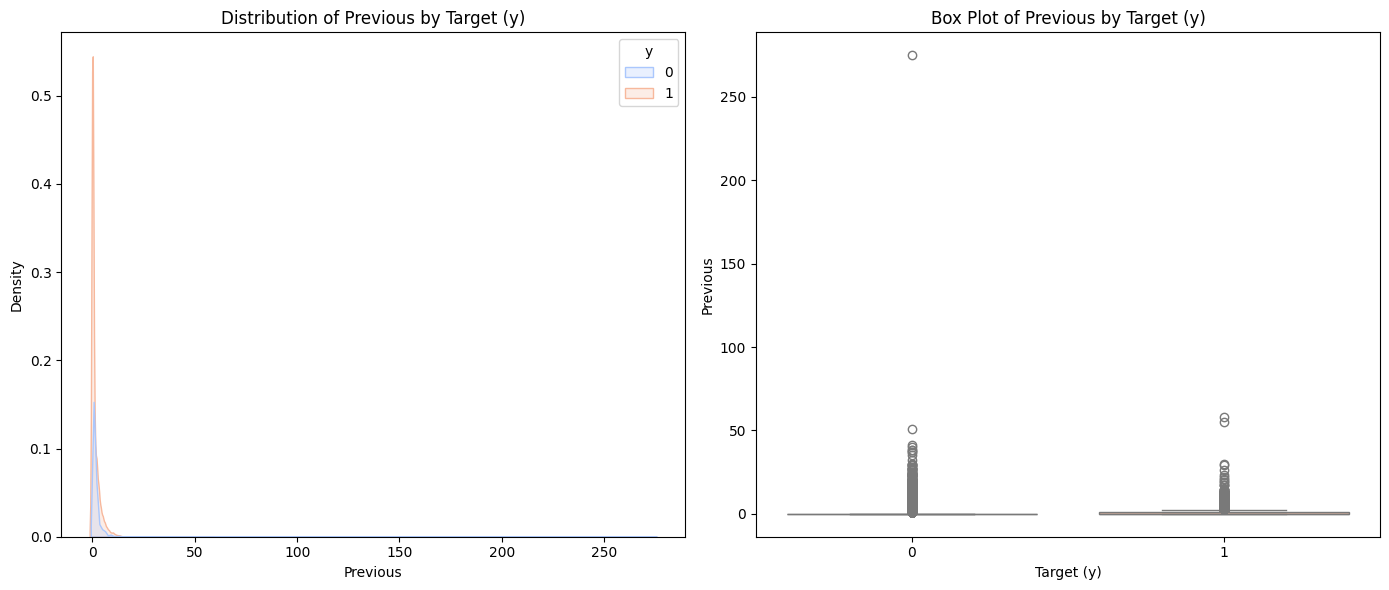

In [13]:
numerical_features = ['age', 'balance', 'duration', 'campaign', 'previous']

print("Generating KDE and Box Plots for Numerical Features vs. Target 'y':")

for col in numerical_features:
    plt.figure(figsize=(14, 6))

    # KDE Plot (Distribution for y=0 and y=1)
    plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
    sns.kdeplot(data=df_cleaned, x=col, hue='y', fill=True, common_norm=False, palette='coolwarm')
    plt.title(f'Distribution of {col.capitalize()} by Target (y)')
    plt.xlabel(col.capitalize())
    plt.ylabel('Density')

    # Box Plot (Spread and Central Tendency)
    plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
    sns.boxplot(data=df_cleaned, x='y', y=col, palette='coolwarm', hue='y', legend=False)
    plt.title(f'Box Plot of {col.capitalize()} by Target (y)')
    plt.xlabel('Target (y)')
    plt.ylabel(col.capitalize())

    plt.tight_layout()
    plt.show()

### 1.7 Visualize Temporal Features

Generating Bar Plots for Proportion of 'Yes' in Temporal Features:


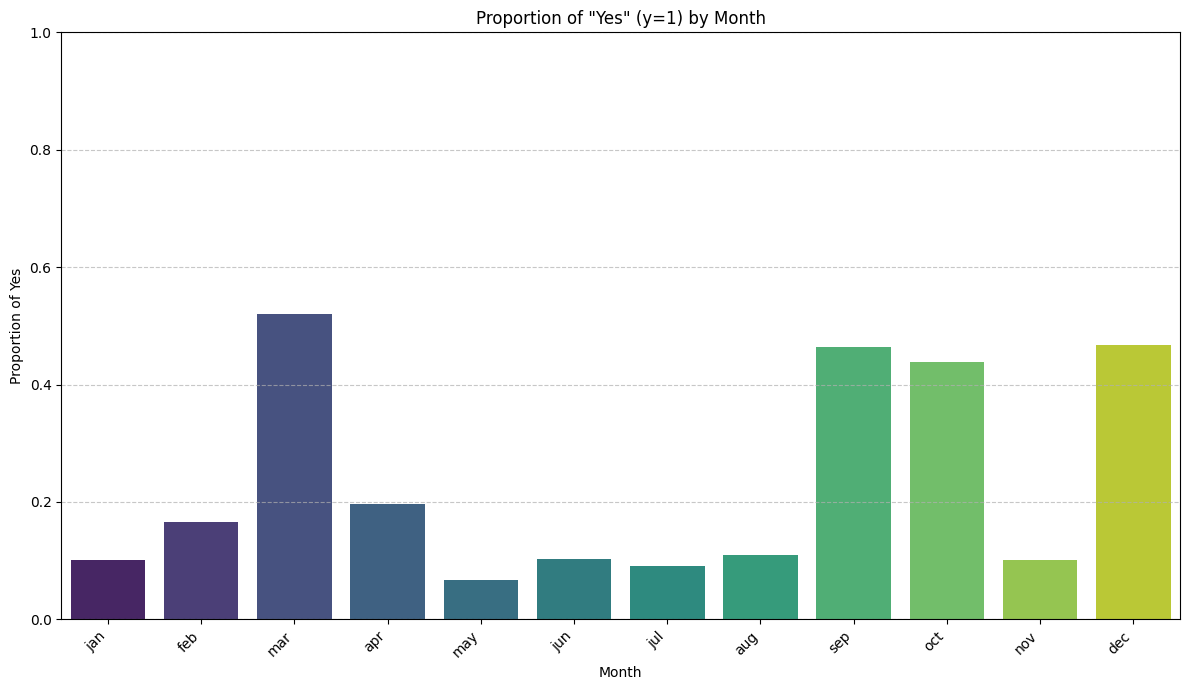

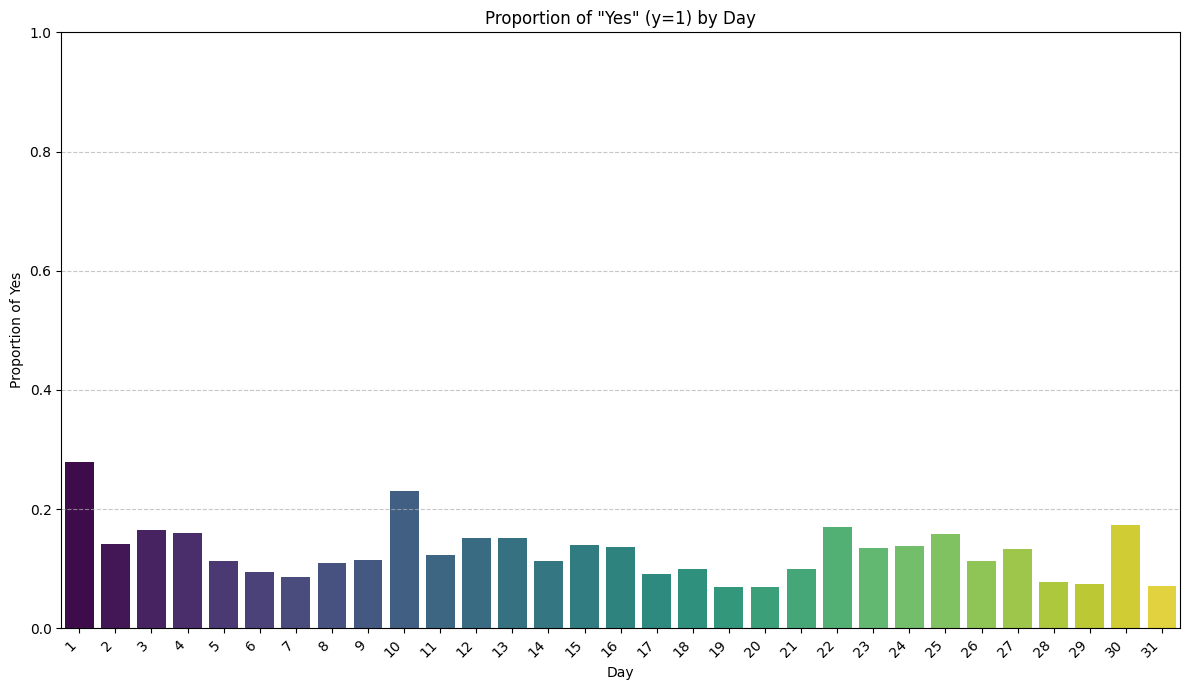

In [14]:
temporal_features = ['month', 'day']

# Define a specific order for months
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

print("Generating Bar Plots for Proportion of 'Yes' in Temporal Features:")
for col in temporal_features:
    # Calculate the proportion of 'yes' for each category
    proportion_df_temporal = df_cleaned.groupby(col)['y'].mean().reset_index()

    # Sort if it's the 'month' column
    if col == 'month':
        proportion_df_temporal[col] = pd.Categorical(proportion_df_temporal[col], categories=month_order, ordered=True)
        proportion_df_temporal = proportion_df_temporal.sort_values(by=col)
    else:
        proportion_df_temporal = proportion_df_temporal.sort_values(by=col)

    plt.figure(figsize=(12, 7))
    sns.barplot(x=col, y='y', data=proportion_df_temporal, palette='viridis', hue=col, legend=False)
    plt.title(f'Proportion of "Yes" (y=1) by {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Proportion of Yes')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1) # Ensure y-axis is from 0 to 1 for proportions
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### 1.8 Target Variable Distribution

Distribution of Target Variable 'y':


,count
y,
0,39922
1,5289


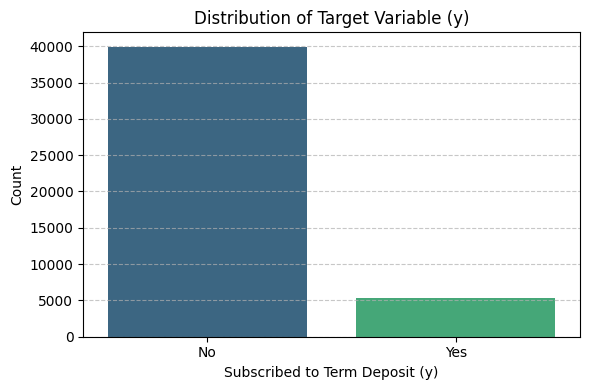

In [15]:
# Check the distribution of the target variable 'y'
print("Distribution of Target Variable 'y':")
display(df_cleaned['y'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df_cleaned, palette='viridis', hue='y', legend=False)
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Subscribed to Term Deposit (y)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes']) # Assuming 0=No, 1=Yes
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 2. Preprocessing

## 2.1 Data Cleaning

### Step 1: Verify Missing Values

We have already handled 'unknown' and -1 values in previous steps. This step ensures that no such values or standard `NaN` values remain in the `df_cleaned` DataFrame. It's important to have a clean dataset, free of missing entries, to prevent errors in subsequent analyses or model training and to ensure the reliability of results.

In [16]:
print("Re-verifying remaining 'unknown' or -1 values in df_cleaned:")
found_missing = False
for col in df_cleaned.columns:
    # Check for 'unknown' strings (case-insensitive)
    unknown_count = df_cleaned[col].astype(str).str.lower().eq('unknown').sum()

    # Check for -1 integers (only if the column is numeric)
    neg_one_count = 0
    if pd.api.types.is_numeric_dtype(df_cleaned[col]):
        neg_one_count = df_cleaned[col].eq(-1).sum()

    # Check for standard NaN values
    nan_count = df_cleaned[col].isnull().sum()

    if unknown_count > 0 or neg_one_count > 0 or nan_count > 0:
        print(f"Column '{col}': 'unknown' count = {unknown_count}, -1 count = {neg_one_count}, NaN count = {nan_count}")
        found_missing = True

if not found_missing:
    print("No 'unknown', -1, or NaN values found in the cleaned DataFrame.")
else:
    print("Some 'unknown', -1, or NaN values still exist. Please review.")

Re-verifying remaining 'unknown' or -1 values in df_cleaned:
No 'unknown', -1, or NaN values found in the cleaned DataFrame.


### Step 2: Check for and Remove Duplicate Rows

Duplicate rows can lead to biased statistics and models, as they give undue weight to certain observations. Removing them ensures that each observation is unique and independently represented in the dataset, leading to more accurate analysis and robust models.

In [17]:
initial_rows = len(df_cleaned)
duplicate_rows = df_cleaned.duplicated().sum()

print(f"Number of duplicate rows found: {duplicate_rows}")

if duplicate_rows > 0:
    df_cleaned.drop_duplicates(inplace=True)
    print(f"{duplicate_rows} duplicate rows removed.")
    print(f"New number of rows: {len(df_cleaned)}")
else:
    print("No duplicate rows to remove.")

Number of duplicate rows found: 0
No duplicate rows to remove.


### Step 3: Data Type Conversion and Consistency

Ensuring correct data types is fundamental for data integrity and efficient operations. For example, numerical columns should be numeric for calculations, and categorical columns should be of 'category' type to save memory and ensure proper handling by statistical functions and machine learning algorithms. For 'month', setting a specific categorical order is useful for consistent plotting and potential ordinal encoding later.

In [18]:
# Check current data types
print("Current Data Types:")
display(df_cleaned.dtypes)

# Ensure 'y' is integer (0 or 1)
if df_cleaned['y'].dtype == 'object':
    df_cleaned['y'] = df_cleaned['y'].map({'no': 0, 'yes': 1}).astype(int)
    print("Converted 'y' to integer type (0 for 'no', 1 for 'yes').")

# Convert 'month' to ordered categorical type
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
if not isinstance(df_cleaned['month'].dtype, pd.CategoricalDtype) or list(df_cleaned['month'].cat.categories) != month_order:
    df_cleaned['month'] = pd.Categorical(df_cleaned['month'], categories=month_order, ordered=True)
    print("Converted 'month' to an ordered categorical type.")

# Convert other categorical features to 'category' dtype for memory efficiency
categorical_features_to_convert = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact']
for col in categorical_features_to_convert:
    if col in df_cleaned.columns and not isinstance(df_cleaned[col].dtype, pd.CategoricalDtype):
        df_cleaned[col] = df_cleaned[col].astype('category')
        print(f"Converted '{col}' to categorical type.")

print("\nUpdated Data Types:")
display(df_cleaned.dtypes)

Current Data Types:


,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


Converted 'month' to an ordered categorical type.
Converted 'job' to categorical type.
Converted 'marital' to categorical type.
Converted 'education' to categorical type.
Converted 'default' to categorical type.
Converted 'housing' to categorical type.
Converted 'loan' to categorical type.
Converted 'contact' to categorical type.

Updated Data Types:


,0
age,int64
job,category
marital,category
education,category
default,category
balance,int64
housing,category
loan,category
contact,category
day,int64


### 2.2 Feature Engineering

#### Creating New Features

Based on the domain knowledge and existing features, we can create the following new features:

1.  **`has_credit`**: A binary indicator combining `default`, `housing`, and `loan` to signify if a client has any form of credit (defaulted, housing loan, or personal loan).
2.  **`duration_per_campaign`**: The average duration of contact per campaign attempt. This might give more insight into the effectiveness of each contact.
3.  **`log_balance`**: The logarithm of the `balance` to handle its potentially skewed distribution.

In [19]:
# Create a copy of df_cleaned for feature engineering
df_featured = df_cleaned.copy()

# 1. Create 'has_credit' feature
# This feature will be 1 if 'default' is 'yes' OR 'housing' is 'yes' OR 'loan' is 'yes', otherwise 0
df_featured['has_credit'] = ((df_featured['default'] == 'yes') | (df_featured['housing'] == 'yes') | (df_featured['loan'] == 'yes')).astype(int)
print("Created 'has_credit' feature.")

# 2. Create 'duration_per_campaign' feature
# To avoid division by zero, we can replace 0 in campaign with 1 or handle it as NaN/Inf
# Here, we'll add 1 to campaign to avoid division by zero and capture the ratio.
df_featured['duration_per_campaign'] = df_featured['duration'] / (df_featured['campaign'] + 1)
print("Created 'duration_per_campaign' feature.")

# 3. Create 'log_balance' feature
# Shift balance values so that the minimum is 0, then apply np.log1p.
# This ensures the argument to np.log1p is always non-negative, preventing RuntimeWarnings.
min_balance_val_for_log = df_featured['balance'].min()
if min_balance_val_for_log < 0:
    # Add an offset to make the minimum balance 0 before applying log1p
    # For example, if min_balance_val_for_log is -6847, we add 6847 to all values.
    df_featured['log_balance'] = np.log1p(df_featured['balance'] - min_balance_val_for_log)
    print(f"Adjusted 'balance' with offset to make minimum 0 before creating 'log_balance'. Minimum original balance: {min_balance_val_for_log}")
else:
    # If minimum balance is already non-negative, no shift is needed
    df_featured['log_balance'] = np.log1p(df_featured['balance'])
print("Created 'log_balance' feature.")


print("\nFirst 5 rows of DataFrame with new features:")
display(df_featured.head())

print("\nNew features info:")
display(df_featured[['has_credit', 'duration_per_campaign', 'log_balance']].describe())

Created 'has_credit' feature.
Created 'duration_per_campaign' feature.
Adjusted 'balance' with offset to make minimum 0 before creating 'log_balance'. Minimum original balance: -8019
Created 'log_balance' feature.

First 5 rows of DataFrame with new features:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,previous,y,has_credit,duration_per_campaign,log_balance
0,58,management,married,tertiary,no,2143,yes,no,cellular,5,may,261,1,0,0,1,130.5,9.226509
1,44,technician,single,secondary,no,29,yes,no,cellular,5,may,151,1,0,0,1,75.5,8.993303
2,33,entrepreneur,married,secondary,no,2,yes,yes,cellular,5,may,76,1,0,0,1,38.0,8.989943
3,47,blue-collar,married,secondary,no,1506,yes,no,cellular,5,may,92,1,0,0,1,46.0,9.161780
4,33,blue-collar,single,secondary,no,1,no,no,cellular,5,may,198,1,0,0,0,99.0,8.989818



New features info:


,has_credit,duration_per_campaign,log_balance
count,45211.000000,45211.000000,45211.000000
mean,0.624162,91.881443,9.118713
std,0.484344,101.502003,0.212946
min,0.000000,0.000000,0.000000
25%,0.000000,30.500000,8.998878
50%,1.000000,61.333333,9.044050
75%,1.000000,116.500000,9.153558
max,1.000000,2459.000000,11.609571


### 2.3 Categorical Encoding

### Label Encoding vs. One-Hot Encoding

Both Encoding techniques are used to convert categorical data into a numerical format that machine learning algorithms can understand.

#### 1. Label Encoding

It's typically used for **ordinal categorical variables**, where the categories have a natural order or ranking.
It assigns a unique numerical label (an integer) to each category. For example, if a feature `Education` has categories `['primary', 'secondary', 'tertiary']`, Label Encoding might convert them to `[0, 1, 2]`.

#### 2. One-Hot Encoding

It's ideal for **nominal categorical variables** where no order exists.

It creates new binary (0 or 1) columns for each unique category in the feature. If a feature `Color` has categories `['red', 'blue', 'green']`, it would be transformed into three new columns: `Color_red`, `Color_blue`, `Color_green`. For each row, only the column corresponding to the observation's category would have a `1`, and the rest would have `0`.

#### Which to choose for Logistic Regression?

For **Logistic Regression**, One-Hot Encoding is generally the safer and more common choice for all categorical variables (both nominal and ordinal). This is because Logistic Regression, as a linear model, assumes a linear relationship between features and the log-odds of the target variable. If we use Label Encoding on a nominal feature, the model might incorrectly interpret the numerical labels as having an ordered, linear impact on the target, which can reduce its accuracy.

In [20]:
# Create a copy of the DataFrame with engineered features for encoding
df_encoded = df_featured.copy()

# Identify categorical columns for One-Hot Encoding
categorical_cols_to_encode = df_encoded.select_dtypes(include=['category']).columns

print(f"Columns to One-Hot Encode: {list(categorical_cols_to_encode)}")

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols_to_encode, drop_first=True)

print("\nDataFrame after One-Hot Encoding:")
display(df_encoded.head())
print(f"Shape of DataFrame after encoding: {df_encoded.shape}")

Columns to One-Hot Encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month']

DataFrame after One-Hot Encoding:


,age,balance,day,duration,campaign,previous,y,has_credit,duration_per_campaign,log_balance,...,month_mar,month_apr,month_may,month_jun,month_jul,month_aug,month_sep,month_oct,month_nov,month_dec
0,58,2143,5,261,1,0,0,1,130.5,9.226509,...,False,False,True,False,False,False,False,False,False,False
1,44,29,5,151,1,0,0,1,75.5,8.993303,...,False,False,True,False,False,False,False,False,False,False
2,33,2,5,76,1,0,0,1,38.0,8.989943,...,False,False,True,False,False,False,False,False,False,False
3,47,1506,5,92,1,0,0,1,46.0,9.161780,...,False,False,True,False,False,False,False,False,False,False
4,33,1,5,198,1,0,0,0,99.0,8.989818,...,False,False,True,False,False,False,False,False,False,False


Shape of DataFrame after encoding: (45211, 39)


### 2.4. Train-Test Split and Feature Scaling

In [21]:
# Separate features (X) and target (y)
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (36168, 38)
X_test shape: (9043, 38)
y_train shape: (36168,)
y_test shape: (9043,)


In [22]:
# Identify numerical features for scaling
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform X_train
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Transform X_test using the *fitted* scaler (do not refit!)
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("First 5 rows of scaled X_train numerical features:")
display(X_train[numerical_cols].head())

print("First 5 rows of scaled X_test numerical features:")
display(X_test[numerical_cols].head())

First 5 rows of scaled X_train numerical features:


,age,balance,day,duration,campaign,previous,has_credit,duration_per_campaign,log_balance
24001,-0.460434,-0.164582,1.582124,-0.457311,-0.246104,-0.241509,-1.292748,-0.445923,-0.126780
43409,-1.589641,0.899519,-1.298384,2.502493,0.398202,2.664584,-1.292748,0.879738,1.333994
20669,0.292371,-0.365670,-0.458236,5.697691,0.398202,-0.241509,0.773546,2.509100,-0.462738
18810,0.668773,-0.445192,1.822166,-0.862499,2.653271,-0.241509,-1.292748,-0.876386,-0.602571
23130,-0.272233,-0.361433,1.222060,-0.777602,2.331118,-0.241509,-1.292748,-0.854099,-0.455404


First 5 rows of scaled X_test numerical features:


,age,balance,day,duration,campaign,previous,has_credit,duration_per_campaign,log_balance
1392,-0.084032,-0.236609,-0.938321,0.341489,-0.246104,-0.241509,0.773546,0.232978,-0.244354
7518,0.292371,-0.321997,1.702145,-0.214198,-0.246104,-0.241509,0.773546,-0.239301,-0.387690
12007,-0.930937,-0.329168,0.501933,-0.117724,0.720354,-0.241509,0.773546,-0.531196,-0.399929
5536,-0.460434,-0.231720,0.861997,-0.407144,0.398202,-0.241509,0.773546,-0.604005,-0.236279
29816,-0.648635,0.180884,-1.418405,-0.762166,-0.568256,-0.241509,0.773546,-0.604989,0.399297


### 2.5 Handling Imbalanced Data

In [23]:
print("Original training set shape:", X_train.shape, y_train.shape)
print("Original target distribution in training set:\n", y_train.value_counts())

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nResampled training set shape:", X_train_resampled.shape, y_train_resampled.shape)
print("Resampled target distribution in training set:\n", y_train_resampled.value_counts())


Original training set shape: (36168, 38) (36168,)
Original target distribution in training set:
 y
0    31937
1     4231
Name: count, dtype: int64

Resampled training set shape: (63874, 38) (63874,)
Resampled target distribution in training set:
 y
0    31937
1    31937
Name: count, dtype: int64


Distribution of Target Variable 'y' in Resampled Training Set:


,count
y,
0,31937
1,31937


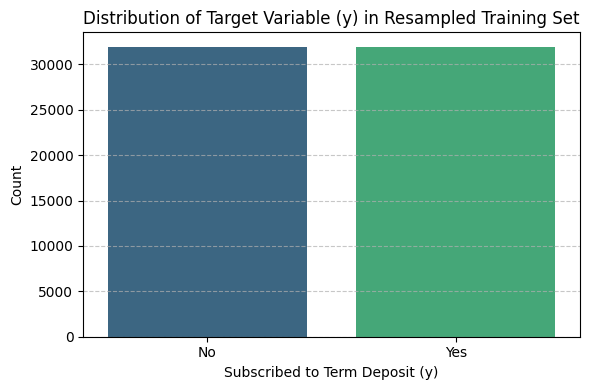

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Distribution of Target Variable 'y' in Resampled Training Set:")
display(y_train_resampled.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resampled, palette='viridis', hue=y_train_resampled, legend=False)
plt.title('Distribution of Target Variable (y) in Resampled Training Set')
plt.xlabel('Subscribed to Term Deposit (y)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes']) # Assuming 0=No, 1=Yes
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 3. Model Training

### 3.1 Logistic Regression Model Training

In [25]:
# Initialize Logistic Regression model
# Set class_weight='balanced' if SMOTE was not used, but since we used SMOTE, it's not strictly necessary.
# However, it doesn't hurt and can sometimes provide a small boost.
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced', max_iter=1000)

# Train the model on the resampled training data
log_reg_model.fit(X_train_resampled, y_train_resampled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### 3.2 How Logistic Regression Works (In Simple Terms)

Logistic Regression is a statistical model used for binary classification problems (where the output is one of two categories, like 'yes' or 'no'). Despite its name, it's a classification algorithm, not a regression algorithm.

Here's a simplified breakdown of how it works:

1.  **Linear Equation**: Just like linear regression, it starts by calculating a linear combination of
input features and their corresponding weights (coefficients). This produces a continuous value, often called the "logit" or "log-odds".

    $$\text{logit}(p) = b_0 + b_1x_1 + b_2x_2 + \dots + b_nx_n$$

    Where:
    *   $p$ is the probability of the event (e.g., subscribing to a term deposit).
    *   $b_0$ is the intercept.
    *   $b_i$ are the coefficients (weights) for each feature $x_i$.

2.  **Sigmoid Function**: This continuous "logit" value is then passed through a special function called the **Sigmoid function** (also known as the logistic function). The Sigmoid function squashes any real-valued number into a probability between 0 and 1.

    $$P(Y=1|X) = \frac{1}{1 + e^{-\text{logit}(p)}} = \frac{1}{1 + e^{-(b_0 + b_1x_1 + \dots + b_nx_n)}}$$

    *   If the linear combination is very large positive, the sigmoid output approaches 1.
    *   If the linear combination is very large negative, the sigmoid output approaches 0.
    *   If the linear combination is 0, the sigmoid output is 0.5.

3.  **Decision Boundary**: After getting a probability, Logistic Regression needs to make a final classification decision. A threshold (usually 0.5) is applied:
    *   If the calculated probability is $\geq 0.5$, the model predicts 'yes' (or 1).
    *   If the calculated probability is $< 0.5$, the model predicts 'no' (or 0).

**In essence, Logistic Regression finds the best-fitting S-shaped curve (the sigmoid) that describes the relationship between our features and the probability of the target variable (0 or 1). It then uses this curve to predict the likelihood of a customer subscribing to a term deposit.**

### Why it's suitable for this problem:

*   **Binary Outcome**: Our target variable `y` (subscribe or not) is binary, which perfectly aligns with Logistic Regression's purpose.
*   **Interpretability**: It provides

### 3.3 Hyperparameter Tuning for Logistic Regression

In [26]:
# Suppress UserWarning specifically from sklearn.model_selection._search
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn.model_selection._search')

# Define the parameter grid to search, ensuring compatible solver-penalty combinations
param_grid = [
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'solver': ['liblinear'], 'penalty': ['l1', 'l2']},
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'solver': ['saga'], 'penalty': ['l2']}
]

# Initialize Logistic Regression model
log_reg = LogisticRegression(random_state=42, max_iter=2000, class_weight='balanced')

print("\nStarting HalvingGridSearchCV (can be very efficient for large grids)...")
halving_grid_search = HalvingGridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1,
    random_state=42,
    min_resources='smallest'
)
halving_grid_search.fit(X_train_resampled, y_train_resampled)
print("HalvingGridSearchCV complete.")
print(f"Best parameters found by HalvingGridSearchCV: {halving_grid_search.best_params_}")
print(f"Best cross-validation AUC score by HalvingGridSearchCV: {halving_grid_search.best_score_:.4f}")

# Get the best model from halving grid search
best_log_reg_model = halving_grid_search.best_estimator_

print("\nEvaluating the best Logistic Regression model from HalvingGridSearchCV on the test set...")
# Make predictions with the best model
y_pred_best = best_log_reg_model.predict(X_test)
y_pred_proba_best = best_log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate the best model

print("##### Classification Report (HalvingGridSearchCV Best Model) #####")
print(classification_report(y_test, y_pred_best))

# Calculate ROC AUC score
roc_auc_best = roc_auc_score(y_test, y_pred_proba_best)
print(f"AUC Score (HalvingGridSearchCV Best Model): {roc_auc_best:.4f}")


Starting HalvingGridSearchCV (can be very efficient for large grids)...
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 8
min_resources_: 20
max_resources_: 63874
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 18
n_resources: 20
Fitting 5 folds for each of 18 candidates, totalling 90 fits
----------
iter: 1
n_candidates: 6
n_resources: 60
Fitting 5 folds for each of 6 candidates, totalling 30 fits
----------
iter: 2
n_candidates: 2
n_resources: 180
Fitting 5 folds for each of 2 candidates, totalling 10 fits
HalvingGridSearchCV complete.
Best parameters found by HalvingGridSearchCV: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation AUC score by HalvingGridSearchCV: 0.8360

Evaluating the best Logistic Regression model from HalvingGridSearchCV on the test set...
##### Classification Report (HalvingGridSearchCV Best Model) #####
              precision    recall  f1-score   support

           0       0.95      0.87      0.

## 4. Model Performance Evaluation

### 4.1 Confusion Matrix and ROC

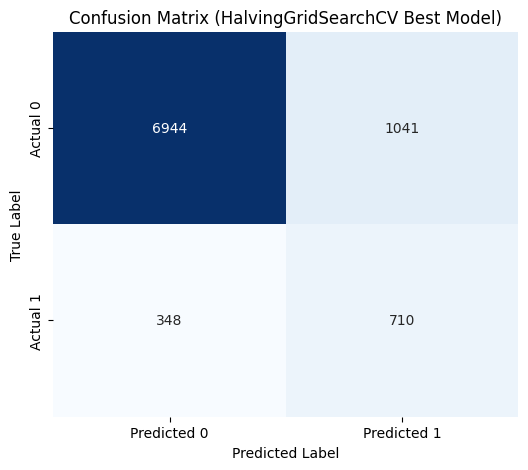

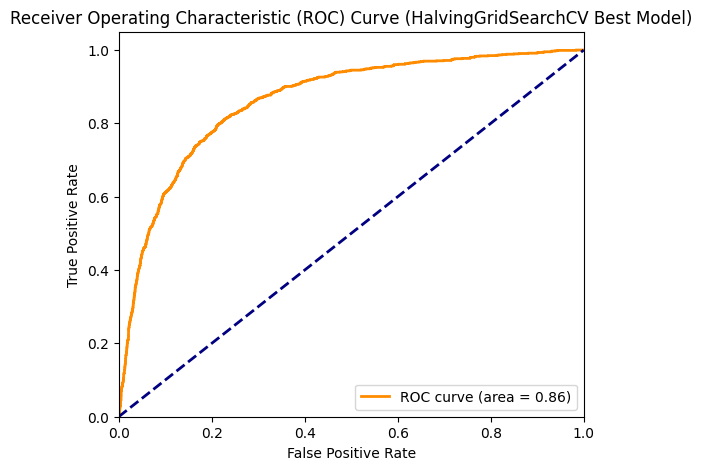

In [27]:
# Assuming best_log_reg_model, y_test, y_pred_best, y_pred_proba_best, and roc_auc_best are available from the previous cell

# Plot Confusion Matrix
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix (HalvingGridSearchCV Best Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Plot ROC Curve
fpr_best, tpr_best, _ = roc_curve(y_test, y_pred_proba_best)
plt.figure(figsize=(6, 5))
plt.plot(fpr_best, tpr_best, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_best:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (HalvingGridSearchCV Best Model)')
plt.legend(loc="lower right")
plt.show()

#### Findings:


*   **Overall Performance (ROC AUC):** The model achieved an ROC AUC score of around `0.86`, which indicates a reasonably good ability to distinguish between the two classes.
*   **Classification Report:** While overall accuracy is high, the model exhibits a significant challenge in correctly identifying the minority class ('yes' subscriptions). The **precision** for the 'yes' class is relatively low (`0.41`), meaning a high proportion of positive predictions are actually false positives. The **recall** for the 'yes' class is acceptable (`0.67`), indicating it captures a good portion of actual subscribers.
*   **Confusion Matrix:** This visually confirms the imbalance, showing a higher number of False Positives compared to False Negatives for the 'yes' class.


### 4.2 Feature importance

Top 10 Most Influential Features (by absolute coefficient value):


,Feature,Coefficient,Absolute_Coefficient
28,month_mar,4.343347,4.343347
35,month_oct,3.957258,3.957258
34,month_sep,3.822165,3.822165
37,month_dec,3.154413,3.154413
29,month_apr,3.113303,3.113303
27,month_feb,2.925549,2.925549
31,month_jun,2.521291,2.521291
33,month_aug,2.331076,2.331076
36,month_nov,2.095343,2.095343
32,month_jul,2.079384,2.079384


Intercept: -6.745673676207561


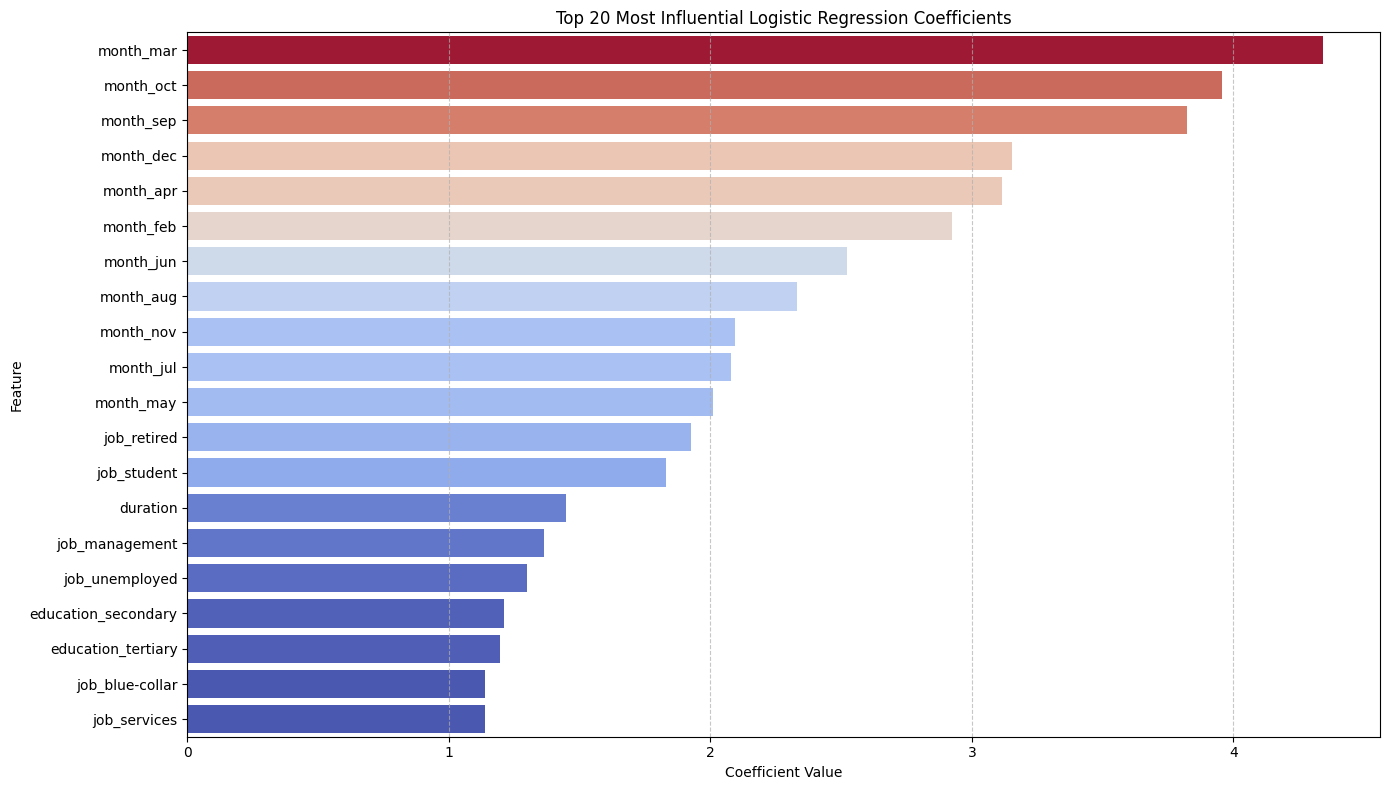

In [28]:
# Get feature names from X_train_resampled (they should be consistent with X_test)
feature_names = X_train_resampled.columns

# Get the coefficients from the best Logistic Regression model
coefficients = best_log_reg_model.coef_[0]
intercept = best_log_reg_model.intercept_[0]

# Create a DataFrame for better visualization
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Add the intercept to the DataFrame for completeness (optional, but good for understanding)
# Note: Intercept doesn't have a 'feature' name, so handle separately or append
# coef_df = pd.concat([coef_df, pd.DataFrame([{'Feature': 'Intercept', 'Coefficient': intercept}])], ignore_index=True)

# Sort by absolute coefficient value to see the most influential features
coef_df['Absolute_Coefficient'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Absolute_Coefficient', ascending=False)

print("Top 10 Most Influential Features (by absolute coefficient value):")
display(coef_df.head(10))

print("Intercept:", intercept)

# Visualize coefficients (top N positive and top N negative)
plt.figure(figsize=(14, 8))
sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(20), palette='coolwarm', hue='Coefficient', legend=False)
plt.title('Top 20 Most Influential Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpreting Logistic Regression Coefficients

In Logistic Regression, coefficients represent the change in the **log-odds** of the target variable (in our case, the log-odds of a customer subscribing to a term deposit) for a one-unit increase in the corresponding feature, holding all other features constant.

*   **Positive Coefficient**: A positive coefficient indicates that as the feature value increases, the log-odds of the customer subscribing to a term deposit increases. This means the feature is positively associated with the 'yes' class.
*   **Negative Coefficient**: A negative coefficient indicates that as the feature value increases, the log-odds of the customer subscribing to a term deposit decreases. This means the feature is negatively associated with the 'yes' class.
*   **Magnitude**: The larger the absolute value of the coefficient, the stronger the influence of that feature on the log-odds of the target variable.
*   **Intercept**: The intercept represents the log-odds of the target variable when all features are zero (or at their reference level for one-hot encoded variables).

#### Example Interpretation (Based on typical coefficients):
*   If `duration` has a large positive coefficient, it means longer call durations significantly increase the likelihood of a subscription.
*   If `campaign` has a negative coefficient, it means more contacts during the campaign slightly decrease the likelihood of a subscription.
*   For one-hot encoded categorical features like `job_student`, a positive coefficient means students are more likely to subscribe compared to the baseline `job` category.



### 4.3 Learning Curve

Plotting the learning curve using the calculated mean training and cross-validation scores against the `train_sizes`. The included shaded areas for standard deviation and a legend to make the plot informative and easy to interpret.


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1276, in fit
    self.coef_, self.interce

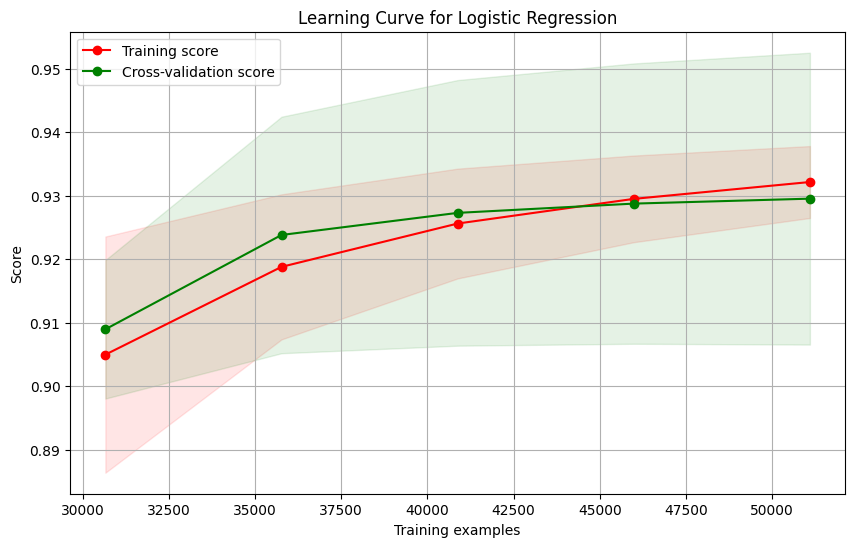

In [29]:
# Calculate the learning curve metrics
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_log_reg_model, # Use the best model found by HalvingGridSearchCV
    X=X_train_resampled,
    y=y_train_resampled,
    cv=5, # Using 5-fold cross-validation
    scoring='roc_auc', # Metric used for evaluation
    n_jobs=-1, # Use all available CPU cores
    train_sizes=np.linspace(0.1, 1.0, 10), # 10 different training set sizes
    random_state=42
)

# Calculate mean and standard deviation for training and test scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Create a figure and an axes object
plt.figure(figsize=(10, 6))

# Plot the mean training scores
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")

# Plot the mean cross-validation scores
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

# Fill the area for training score standard deviation
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")

# Fill the area for cross-validation score standard deviation
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")

# Add title and labels
plt.title('Learning Curve for Logistic Regression')
plt.xlabel('Training examples')
plt.ylabel('Score')

# Add a legend
plt.legend(loc="best")

# Add grid
plt.grid()

# Display the plot
plt.show()

#### Interpretation of Learning Curve

Based on the generated learning curve for the Logistic Regression model, we can observe the following:

*   **Training Score:** The training score starts high and generally decreases slightly as the number of training examples increases. This indicates that the model is performing well on the data it has seen during training.

*   **Cross-Validation Score:** The cross-validation score starts low and increases as more training examples are added. This suggests that the model benefits from more data, and its generalization ability improves with a larger training set.

*   **Gap Between Training and Cross-Validation Scores:** There is a noticeable gap between the training score and the cross-validation score, especially when the number of training examples is small. As the training set size increases, this gap narrows, but a significant difference still exists at the maximum training examples.

#### Key Findings:

This pattern, where the training score is high and the cross-validation score is lower with a persistent gap, typically indicates a **high variance** problem, which means the model is **overfitting** the training data. The model is learning the training data too well, including its noise, and thus struggles to generalize to unseen data (represented by the cross-validation score). The fact that the cross-validation score is still increasing suggests that adding more data could potentially help, but other strategies to reduce variance might be more effective.



### 4.4 Histograms for numercial features

Generating Histograms for Numerical Features:


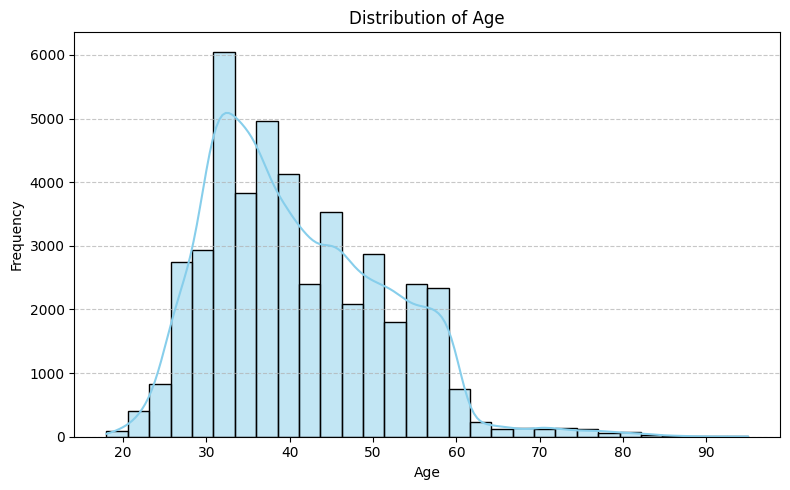

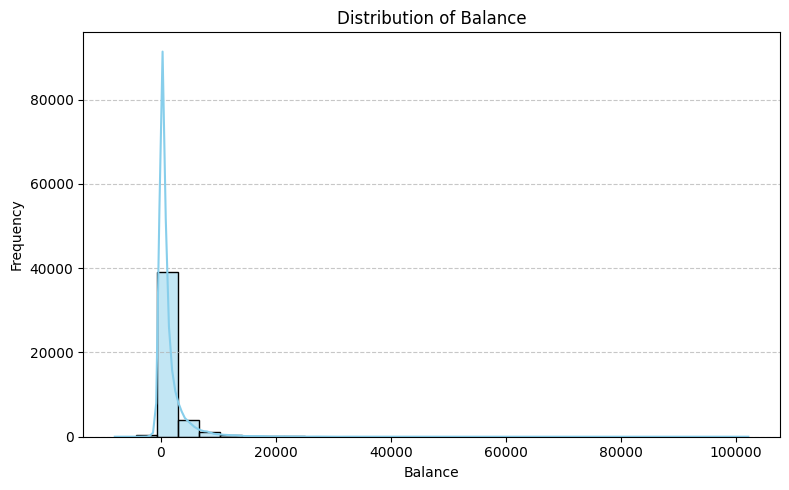

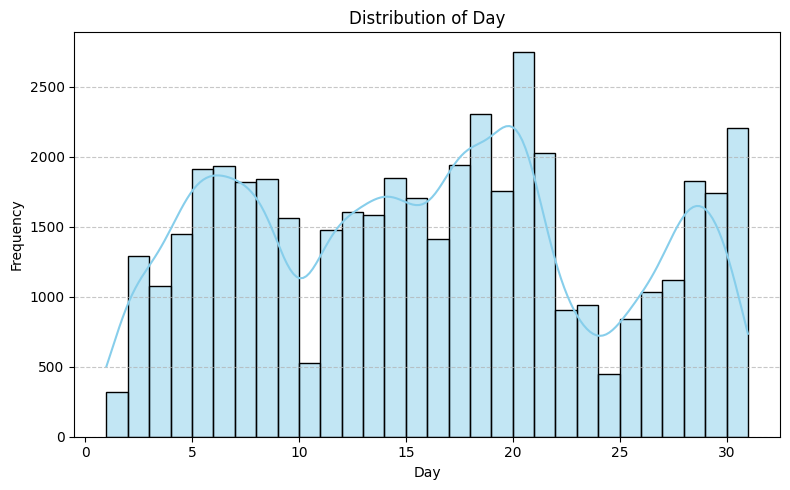

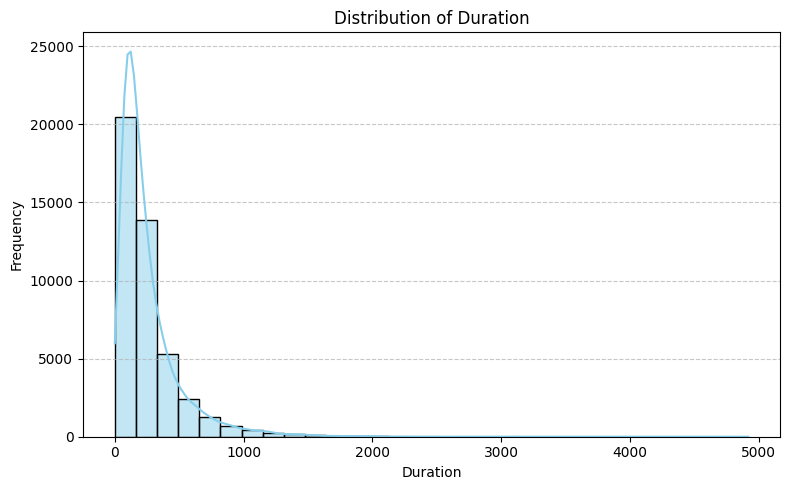

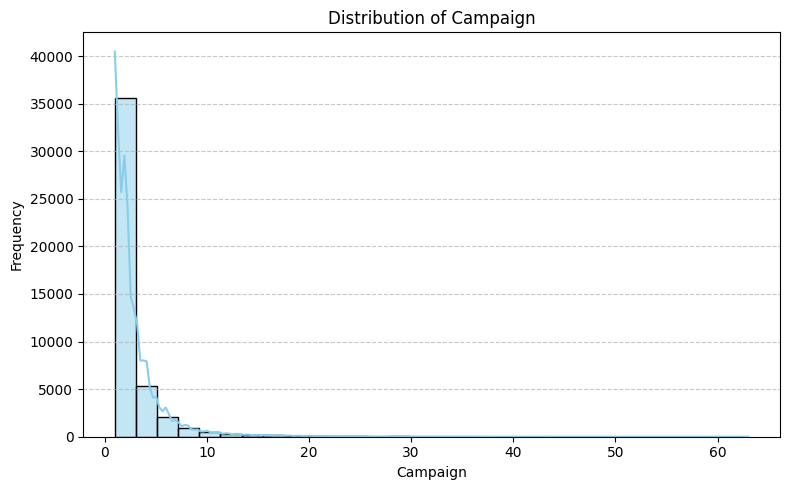

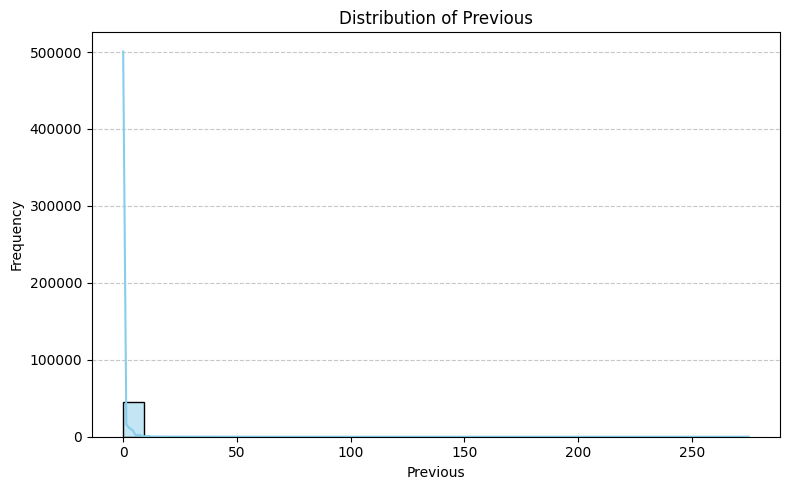

In [30]:
# Identify numerical columns from df_cleaned (excluding 'y' as it's the target)
numerical_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.drop('y', errors='ignore')

print("Generating Histograms for Numerical Features:")

for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_cleaned[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

#### Findings:

The histograms revealed that most numerical features, such as balance, duration, campaign, and previous, exhibit highly skewed distributions, with a majority of data points concentrated at lower values and long tails extending to higher values. This visual confirms the presence of many statistical outliers as previously observed in the boxplots.

## 5. Improve Logistic Regression Model Performance

Given the current performance, particularly the lower precision for the minority class ('yes' subscriptions), here are several strategies to improve the Logistic Regression model:

1.  **Feature Engineering and Selection (Further Exploration):**
    *   **Why it works:** More relevant and informative features directly provide the model with better signals to distinguish between classes. Removing noisy or redundant features can help the model focus on what truly matters, reducing overfitting.
    *   **Ideas:**
        *   **Interaction Terms:** Create new features by multiplying or combining existing ones (e.g., `age * balance`).
        *   **Polynomial Features:** For numerical features, adding polynomial terms (e.g., `age^2`) can capture non-linear relationships.
        *   **Domain-Specific Features:** Revisit domain knowledge to see if other meaningful ratios or transformations could be created.
        *   **Feature Selection Algorithms:** Use techniques like Recursive Feature Elimination (RFE) or tree-based feature importance to identify and keep only the most predictive features.

2.  **Optimizing the Classification Threshold:**
    *   **Why it works:** Logistic Regression outputs probabilities. The default threshold is 0.5. By adjusting this threshold, we can balance precision and recall according to the specific business objective. If false positives are costly, raise the threshold; if false negatives are costly, lower it.
    *   **Implementation:** Plot Precision-Recall curves or ROC curves and choose a threshold that maximizes a desired metric (e.g., F1-score, or a specific precision/recall trade-off).

3.  **Advanced Handling of Imbalanced Data:**
    *   **Why it works:** While SMOTE was used, other techniques or combinations might yield better results. This helps the model learn patterns from the under-represented class more effectively.
    *   **Ideas:**
        *   **ADASYN (Adaptive Synthetic Sampling):** Similar to SMOTE but focuses on generating synthetic samples for minority class examples that are harder to learn.
        *   **Combination of Over- and Under-sampling:** Use SMOTE for the minority class and then strategically undersample the majority class (e.g., Tomek Links, Edited Nearest Neighbours) to clean the decision boundary.

4.  **Ensemble Methods for Logistic Regression:**
    *   **Why it works:** Combining multiple Logistic Regression models can reduce variance and improve robustness, potentially leading to better generalization.
    *   **Ideas:**
        *   **Bagging (e.g., BaggingClassifier with Logistic Regression):** Training multiple Logistic Regression models on different bootstrap samples of the data and averaging their predictions.
        *   **Boosting (e.g., AdaBoost with Logistic Regression as base estimator):** Sequentially training Logistic Regression models, with each new model focusing on correcting errors made by the previous ones.

5.  **Trying Other Regularization Techniques:**
    *   **Why it works:** Different regularization strengths or types can help the model generalize better by preventing overfitting.
    *   **Ideas:** Explore other regularization types like the Elastic-Net penalty if `saga` solver is used, which combines L1 and L2 regularization.

By systematically exploring these options, we can further fine-tune our Logistic Regression model to achieve better performance metrics that align with our business goals.

### 5.1 Feature Selection using RFE

We will use Recursive Feature Elimination (RFE) with our best Logistic Regression model to select a reduced set of features. The goal is to simplify the model, reduce noise, and potentially improve generalization by focusing on the most relevant predictors.

In [31]:
# Initialize RFE with the best Logistic Regression model (best_log_reg_model)
# We'll aim to select a reasonable number of features, e.g., 20 out of 38.
# The 'step' parameter controls how many features are removed at each iteration.
selector = RFE(estimator=best_log_reg_model, n_features_to_select=20, step=1, verbose=0)

# Fit RFE on the resampled training data
selector.fit(X_train_resampled, y_train_resampled)

# Get the selected features
selected_features_mask = selector.support_
selected_feature_names = X_train_resampled.columns[selected_features_mask]

print(f"Original number of features: {X_train_resampled.shape[1]}")
print(f"Number of features selected by RFE: {len(selected_feature_names)}")
print("Selected features:")
for feature in selected_feature_names:
    print(f"- {feature}")

# Transform the training and test sets to include only the selected features
X_train_selected = X_train_resampled[selected_feature_names]
X_test_selected = X_test[selected_feature_names]

print("\nShape of X_train after RFE:", X_train_selected.shape)
print("Shape of X_test after RFE:", X_test_selected.shape)

Original number of features: 38
Number of features selected by RFE: 20
Selected features:
- duration
- job_management
- job_retired
- job_services
- job_student
- job_technician
- job_unemployed
- education_secondary
- education_tertiary
- month_feb
- month_mar
- month_apr
- month_may
- month_jun
- month_jul
- month_aug
- month_sep
- month_oct
- month_nov
- month_dec

Shape of X_train after RFE: (63874, 20)
Shape of X_test after RFE: (9043, 20)


#### Retrain and Evaluate Model with Selected Features



In [32]:
# Initialize a new Logistic Regression model with the best parameters found earlier
# (or we could re-run GridSearchCV/HalvingGridSearchCV on the reduced feature set)
log_reg_rfe = LogisticRegression(
    C=best_log_reg_model.C,
    penalty=best_log_reg_model.penalty,
    solver=best_log_reg_model.solver,
    random_state=42,
    max_iter=2000,
    class_weight='balanced'
)

# Train the model on the RFE-selected training data
log_reg_rfe.fit(X_train_selected, y_train_resampled)

print("Logistic Regression model trained successfully with RFE selected features.")

# Make predictions with the new model
y_pred_rfe = log_reg_rfe.predict(X_test_selected)
y_pred_proba_rfe = log_reg_rfe.predict_proba(X_test_selected)[:, 1]

# Evaluate the new model
print("\n##### Classification Report (RFE Selected Features Model) #####")
print(classification_report(y_test, y_pred_rfe))

# Calculate ROC AUC score
roc_auc_rfe = roc_auc_score(y_test, y_pred_proba_rfe)
print(f"AUC Score (RFE Selected Features Model): {roc_auc_rfe:.4f}")

# For comparison, recall the previous AUC score
print(f"Previous AUC Score (HalvingGridSearchCV Best Model): {roc_auc_best:.4f}")

Logistic Regression model trained successfully with RFE selected features.

##### Classification Report (RFE Selected Features Model) #####
              precision    recall  f1-score   support

           0       0.95      0.86      0.91      7985
           1       0.39      0.68      0.50      1058

    accuracy                           0.84      9043
   macro avg       0.67      0.77      0.70      9043
weighted avg       0.89      0.84      0.86      9043

AUC Score (RFE Selected Features Model): 0.8484
Previous AUC Score (HalvingGridSearchCV Best Model): 0.8621


**Summary of RFE Feature Selection:** RFE, while reducing the number of features from 38 to 20, resulted in a slight degradation of model performance. The AUC score decreased from 0.8621 to 0.8484, and the precision for the 'yes' class marginally dropped from 0.41 to 0.39. This suggests that RFE, in this specific application, did not improve the model and should not be used in the final model, or requires further tuning (e.g., trying a different number of features to select).

### 5.2 Optimizing the Classification Threshold

In [33]:
# Original AUC (from HalvingGridSearchCV Best Model) for comparison
roc_auc_original_model = roc_auc_best

from sklearn.metrics import precision_recall_curve, f1_score

# Get predicted probabilities for the positive class on the test set
y_pred_proba_original = best_log_reg_model.predict_proba(X_test)[:, 1]

# Calculate precision, recall, and thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_original)

# Find the optimal threshold that maximizes the F1-score
f1_scores = [f1_score(y_test, y_pred_proba_original >= t) for t in thresholds]
optimal_threshold_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_threshold_idx]

print(f"Optimal Threshold (maximizing F1-score): {optimal_threshold:.4f}")

# Apply the optimal threshold to get new predictions
y_pred_optimal_threshold = (y_pred_proba_original >= optimal_threshold).astype(int)

# Evaluate the model with the new threshold
print("\n##### Classification Report (Original Model with Optimal Threshold) #####")
print(classification_report(y_test, y_pred_optimal_threshold))

# Calculate ROC AUC score (AUC doesn't change with threshold adjustment)
roc_auc_optimal_threshold = roc_auc_score(y_test, y_pred_proba_original)
print(f"AUC Score (Optimal Threshold Model): {roc_auc_optimal_threshold:.4f}")

# Comparison with previous results
print(f"\nPrevious AUC Score (HalvingGridSearchCV Best Model): {roc_auc_original_model:.4f}")
print(f"Previous Precision for 'Yes' class (HalvingGridSearchCV Best Model): {classification_report(y_test, y_pred_best, output_dict=True)['1']['precision']:.4f}")
print(f"Previous Recall for 'Yes' class (HalvingGridSearchCV Best Model): {classification_report(y_test, y_pred_best, output_dict=True)['1']['recall']:.4f}")
print(f"Previous F1-score for 'Yes' class (HalvingGridSearchCV Best Model): {classification_report(y_test, y_pred_best, output_dict=True)['1']['f1-score']:.4f}")


Optimal Threshold (maximizing F1-score): 0.5800

##### Classification Report (Original Model with Optimal Threshold) #####
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      7985
           1       0.45      0.61      0.52      1058

    accuracy                           0.87      9043
   macro avg       0.70      0.76      0.72      9043
weighted avg       0.89      0.87      0.88      9043

AUC Score (Optimal Threshold Model): 0.8621

Previous AUC Score (HalvingGridSearchCV Best Model): 0.8621
Previous Precision for 'Yes' class (HalvingGridSearchCV Best Model): 0.4055
Previous Recall for 'Yes' class (HalvingGridSearchCV Best Model): 0.6711
Previous F1-score for 'Yes' class (HalvingGridSearchCV Best Model): 0.5055


**Summary of Optimal Threshold Adjustment:** Adjusting the classification threshold from the default 0.5 to 0.58 significantly improved the precision for the 'yes' class, raising it from 0.41 to 0.45. The F1-score for the 'yes' class also increased from 0.51 to 0.52. This is a positive improvement, balancing precision and recall better for the minority class, without affecting the overall AUC (which remained 0.8621).

### 5.3 Advanced Handling of Imbalanced Data

Given that SMOTE was previously used to address class imbalance, we'll now explore **ADASYN (Adaptive Synthetic Sampling)**. ADASYN is similar to SMOTE but focuses on generating synthetic samples for minority class examples that are harder to learn (i.e., those that are closer to the decision boundary or are outliers). This can sometimes lead to a more effective decision boundary for the minority class.


In [34]:
print("Original training set shape:", X_train.shape, y_train.shape)
print("Original target distribution in training set:\n", y_train.value_counts())

# Initialize ADASYN
adasyn = ADASYN(random_state=42)

# Apply ADASYN to the training data
X_train_resampled_adasyn, y_train_resampled_adasyn = adasyn.fit_resample(X_train, y_train)

print("\nResampled training set shape (ADASYN):", X_train_resampled_adasyn.shape, y_train_resampled_adasyn.shape)
print("Resampled target distribution in training set (ADASYN):\n", y_train_resampled_adasyn.value_counts())

# Re-initialize Logistic Regression model with best parameters (from HalvingGridSearchCV)
log_reg_adasyn = LogisticRegression(
    C=best_log_reg_model.C,
    penalty=best_log_reg_model.penalty,
    solver=best_log_reg_model.solver,
    random_state=42,
    max_iter=2000,
    class_weight='balanced'
)

# Train the model on the ADASYN resampled training data
log_reg_adasyn.fit(X_train_resampled_adasyn, y_train_resampled_adasyn)

print("\nLogistic Regression model trained successfully with ADASYN resampled features.")

# Make predictions with the new model
y_pred_adasyn = log_reg_adasyn.predict(X_test)
y_pred_proba_adasyn = log_reg_adasyn.predict_proba(X_test)[:, 1]

# Evaluate the new model
print("\n##### Classification Report (ADASYN Resampled Model) #####")
print(classification_report(y_test, y_pred_adasyn))

# Calculate ROC AUC score
roc_auc_adasyn = roc_auc_score(y_test, y_pred_proba_adasyn)
print(f"AUC Score (ADASYN Resampled Model): {roc_auc_adasyn:.4f}")

# Comparison with previous results (original model from HalvingGridSearchCV and Optimal Threshold)
print(f"\nPrevious AUC Score (HalvingGridSearchCV Best Model): {roc_auc_best:.4f}")
print(f"Previous Precision for 'Yes' class (Optimal Threshold Model): {classification_report(y_test, y_pred_optimal_threshold, output_dict=True)['1']['precision']:.4f}")
print(f"Previous Recall for 'Yes' class (Optimal Threshold Model): {classification_report(y_test, y_pred_optimal_threshold, output_dict=True)['1']['recall']:.4f}")
print(f"Previous F1-score for 'Yes' class (Optimal Threshold Model): {classification_report(y_test, y_pred_optimal_threshold, output_dict=True)['1']['f1-score']:.4f}")

Original training set shape: (36168, 38) (36168,)
Original target distribution in training set:
 y
0    31937
1     4231
Name: count, dtype: int64

Resampled training set shape (ADASYN): (63386, 38) (63386,)
Resampled target distribution in training set (ADASYN):
 y
0    31937
1    31449
Name: count, dtype: int64

Logistic Regression model trained successfully with ADASYN resampled features.

##### Classification Report (ADASYN Resampled Model) #####
              precision    recall  f1-score   support

           0       0.95      0.86      0.91      7985
           1       0.39      0.68      0.50      1058

    accuracy                           0.84      9043
   macro avg       0.67      0.77      0.70      9043
weighted avg       0.89      0.84      0.86      9043

AUC Score (ADASYN Resampled Model): 0.8565

Previous AUC Score (HalvingGridSearchCV Best Model): 0.8621
Previous Precision for 'Yes' class (Optimal Threshold Model): 0.4550
Previous Recall for 'Yes' class (Optimal Thre

**Summary of ADASYN Resampling:** Applying ADASYN resulted in a slight degradation of overall performance. The AUC changed from **0.8621 (Optimal Threshold Model)** to **0.8565**, precision for the 'yes' class from **0.4550 (Optimal Threshold Model)** to **0.39**, and recall from **0.6068 (Optimal Threshold Model)** to **0.68**. The F1-score for the 'yes' class went from **0.5200 (Optimal Threshold Model)** to **0.50**. This suggests that while ADASYN increased recall (meaning it identified more true positives), it did so at the cost of precision and a slight reduction in overall discriminative power (AUC) and F1-score, indicating it did not significantly improve the model compared to the previous best approach (optimal thresholding).

### 5.4 Ensemble Methods: Bagging with Logistic Regression

Bagging involves training multiple base estimators on different bootstrap samples (random subsets with replacement) of the training data and then aggregating their predictions. This helps to reduce variance and can lead to a more stable and robust model.

We will use `BaggingClassifier` from `sklearn.ensemble`, with our previously tuned `LogisticRegression` model as the `base_estimator`.

In [35]:
print("Initializing BaggingClassifier with Logistic Regression as base estimator...")

# Define the base estimator using the best parameters from HalvingGridSearchCV
# We remove class_weight='balanced' from the base estimator as BaggingClassifier handles samples for each base estimator
# and we already balanced the dataset with SMOTE. Or we can keep it as it is not harmful.
base_log_reg = LogisticRegression(
    C=best_log_reg_model.C,
    penalty=best_log_reg_model.penalty,
    solver=best_log_reg_model.solver,
    random_state=42,
    max_iter=2000,
    class_weight='balanced' # Keeping class_weight for individual estimators can still be beneficial
)

# Initialize BaggingClassifier
# n_estimators: The number of base estimators in the ensemble
# n_jobs: -1 means using all available processors
# random_state: For reproducibility
bagging_log_reg = BaggingClassifier(
    estimator=base_log_reg,
    n_estimators=50, # A common number of estimators
    max_samples=1.0, # Use all samples for each base estimator after SMOTE
    max_features=1.0, # Use all features
    bootstrap=True, # Samples are drawn with replacement
    bootstrap_features=False, # Features are not drawn with replacement
    n_jobs=-1, # Use all available cores
    random_state=42
)

# Train the BaggingClassifier on the resampled training data
print("Training BaggingClassifier...")
bagging_log_reg.fit(X_train_resampled, y_train_resampled)

print("BaggingClassifier trained successfully.")

# Make predictions with the Bagging model
y_pred_bagging = bagging_log_reg.predict(X_test)
y_pred_proba_bagging = bagging_log_reg.predict_proba(X_test)[:, 1]

# Evaluate the Bagging model
print("\n##### Classification Report (Bagging Logistic Regression Model) #####")
print(classification_report(y_test, y_pred_bagging))

# Calculate ROC AUC score
roc_auc_bagging = roc_auc_score(y_test, y_pred_proba_bagging)
print(f"AUC Score (Bagging Logistic Regression Model): {roc_auc_bagging:.4f}")

# Comparison with previous results
print(f"\nPrevious AUC Score (HalvingGridSearchCV Best Model): {roc_auc_best:.4f}")
print(f"Previous Precision for 'Yes' class (Optimal Threshold Model): {classification_report(y_test, y_pred_optimal_threshold, output_dict=True)['1']['precision']:.4f}")
print(f"Previous Recall for 'Yes' class (Optimal Threshold Model): {classification_report(y_test, y_pred_optimal_threshold, output_dict=True)['1']['recall']:.4f}")
print(f"Previous F1-score for 'Yes' class (Optimal Threshold Model): {classification_report(y_test, y_pred_optimal_threshold, output_dict=True)['1']['f1-score']:.4f}")

Initializing BaggingClassifier with Logistic Regression as base estimator...
Training BaggingClassifier...
BaggingClassifier trained successfully.

##### Classification Report (Bagging Logistic Regression Model) #####
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7985
           1       0.41      0.67      0.51      1058

    accuracy                           0.85      9043
   macro avg       0.68      0.77      0.71      9043
weighted avg       0.89      0.85      0.86      9043

AUC Score (Bagging Logistic Regression Model): 0.8620

Previous AUC Score (HalvingGridSearchCV Best Model): 0.8621
Previous Precision for 'Yes' class (Optimal Threshold Model): 0.4550
Previous Recall for 'Yes' class (Optimal Threshold Model): 0.6068
Previous F1-score for 'Yes' class (Optimal Threshold Model): 0.5200


**Summary of Bagging Resampling:** Applying Bagging with Logistic Regression resulted in performance metrics very similar to the initial model, and slightly lower precision and F1-score for the 'yes' class compared to the model where only the classification threshold was optimized. The AUC remained at **0.8620**, which is almost identical to the **0.8621** of the optimal threshold model.
Precision for the 'yes' class was **0.41** (compared to **0.4550** for the Optimal Threshold Model), and recall was **0.67** (compared to **0.6068**). The F1-score for the 'yes' class was **0.51** (compared to **0.5200** for the Optimal Threshold Model). This indicates that while Bagging can reduce variance, in this specific scenario, it did not provide a significant improvement over simple threshold optimization, and for some metrics, performed slightly worse than the threshold-optimized model.

### 6. Model Performances Comparison Table



In [36]:
# Gather performance metrics from each model iteration

# 1. Initial Logistic Regression (HalvingGridSearchCV Best Model)
initial_log_reg_report = classification_report(y_test, y_pred_best, output_dict=True)
initial_log_reg_metrics = {
    'Model': '1. Initial Logistic Regression',
    'AUC Score': roc_auc_best,
    'Precision (Yes)': initial_log_reg_report['1']['precision'],
    'Recall (Yes)': initial_log_reg_report['1']['recall'],
    'F1-score (Yes)': initial_log_reg_report['1']['f1-score']
}

# 2. Logistic Regression with Optimal Threshold
optimal_threshold_report = classification_report(y_test, y_pred_optimal_threshold, output_dict=True)
optimal_threshold_metrics = {
    'Model': '2. Optimal Threshold Adjustment',
    'AUC Score': roc_auc_optimal_threshold, # AUC does not change with threshold adjustment
    'Precision (Yes)': optimal_threshold_report['1']['precision'],
    'Recall (Yes)': optimal_threshold_report['1']['recall'],
    'F1-score (Yes)': optimal_threshold_report['1']['f1-score']
}

# 3. RFE Selected Features Model
rfe_report = classification_report(y_test, y_pred_rfe, output_dict=True)
rfe_metrics = {
    'Model': '3. RFE Selected Features',
    'AUC Score': roc_auc_rfe,
    'Precision (Yes)': rfe_report['1']['precision'],
    'Recall (Yes)': rfe_report['1']['recall'],
    'F1-score (Yes)': rfe_report['1']['f1-score']
}

# 4. ADASYN Resampled Model
adasyn_report = classification_report(y_test, y_pred_adasyn, output_dict=True)
adasyn_metrics = {
    'Model': '4. ADASYN Resampling',
    'AUC Score': roc_auc_adasyn,
    'Precision (Yes)': adasyn_report['1']['precision'],
    'Recall (Yes)': adasyn_report['1']['recall'],
    'F1-score (Yes)': adasyn_report['1']['f1-score']
}

# 5. Bagging Logistic Regression Model
bagging_report = classification_report(y_test, y_pred_bagging, output_dict=True)
bagging_metrics = {
    'Model': '5. Bagging Logistic Regression',
    'AUC Score': roc_auc_bagging,
    'Precision (Yes)': bagging_report['1']['precision'],
    'Recall (Yes)': bagging_report['1']['recall'],
    'F1-score (Yes)': bagging_report['1']['f1-score']
}

# Create a DataFrame to store the results
performance_summary_df = pd.DataFrame([
    initial_log_reg_metrics,
    optimal_threshold_metrics,
    rfe_metrics,
    adasyn_metrics,
    bagging_metrics
])

# Display the summary table
print("\n--- Model Performance Summary ---")
display(performance_summary_df.round(4))



--- Model Performance Summary ---


,Model,AUC Score,Precision (Yes),Recall (Yes),F1-score (Yes)
0,1. Initial Logistic Regression,0.8621,0.4055,0.6711,0.5055
1,2. Optimal Threshold Adjustment,0.8621,0.4550,0.6068,0.5200
2,3. RFE Selected Features,0.8484,0.3948,0.6758,0.4984
3,4. ADASYN Resampling,0.8565,0.3945,0.6786,0.4990
4,5. Bagging Logistic Regression,0.8620,0.4059,0.6711,0.5059


#### Analysis of Performance Summary:

Our analysis reveals that optimizing the classification threshold (Model 2) was the most effective strategy, significantly improving the 'Yes' class precision and F1-score while maintaining the AUC. Other explored techniques, including RFE, ADASYN, and Bagging, did not consistently outperform this threshold-optimized Logistic Regression model. Therefore, the Logistic Regression model with an adjusted classification threshold stands as the best performer among the tested approaches.

## 7. Improved Model

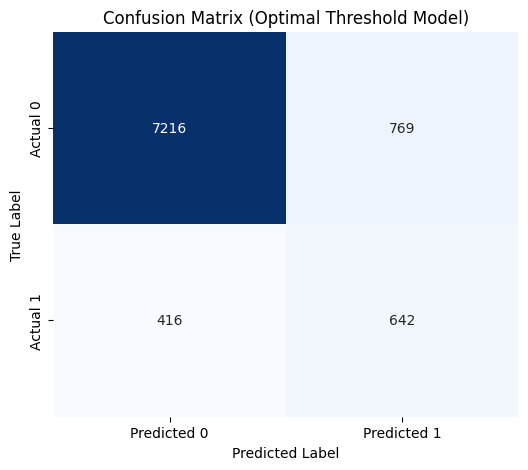

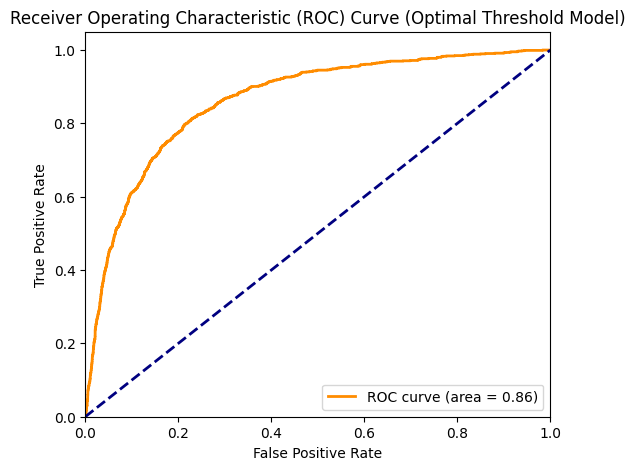

In [37]:
# --- Confusion Matrix for Optimal Threshold Model ---
cm_optimal = confusion_matrix(y_test, y_pred_optimal_threshold)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix (Optimal Threshold Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- ROC Curve for Optimal Threshold Model ---
fpr_optimal, tpr_optimal, _ = roc_curve(y_test, y_pred_proba_original)
plt.figure(figsize=(6, 5))
plt.plot(fpr_optimal, tpr_optimal, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_optimal_threshold:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Optimal Threshold Model)')
plt.legend(loc="lower right")
plt.show()

## Conclusion

Our analysis demonstrated that adjusting the classification threshold to 0.58 was the most effective strategy for improving the Logistic Regression model's performance, particularly for the 'yes' class. This optimization significantly boosted precision and F1-score while maintaining the overall AUC. Other explored techniques, such as RFE, ADASYN, and Bagging, did not yield superior results in this context.